## Analyzing single-cell RNA-seq data (clustering and cell type annotations)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Installation & Importing Packages

In [ ]:
!pip install scanpy #--target '/content/drive/MyDrive/Colab Notebooks/Colab_packages'

In [ ]:
#need to install these too
#!conda install -y -c anaconda cmake
!pip install leidenalg #--target '/content/drive/MyDrive/Colab Notebooks/Colab_packages'
!pip install louvain #--target '/content/drive/MyDrive/Colab Notebooks/Colab_packages'

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import scanpy as sc
import anndata

In [ ]:
sc.settings.verbosity = 3             # verbosity: errors (0),                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.3 anndata==0.9.1 umap==0.5.3 numpy==1.22.4 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.2 statsmodels==0.13.5 python-igraph==0.10.4 louvain==0.8.0 pynndescent==0.5.10


## Data Load

In [ ]:
adata = sc.read("/content/drive/MyDrive/Colab Notebooks/ESCA/SCG_2023/Week3/Melanoma_2000.h5ad")

In [ ]:
adata

AnnData object with n_obs × n_vars = 2000 × 23686
    obs: 'tumor', 'Malignant', 'Non_malignant'

In [ ]:
adata.obs['tumor'] = adata.obs['tumor'].astype('object')
adata.obs['Malignant'] = adata.obs['Malignant'].astype('object')
adata.obs['Non_malignant'] = adata.obs['Non_malignant'].astype('object')

In [ ]:
adata.obs.Malignant.value_counts()

1    1359
2     482
0      79
Name: Malignant, dtype: int64

In [ ]:
#remove unknowns
adata2 = adata[~(adata.obs["Malignant"]==0)]
adata2

View of AnnData object with n_obs × n_vars = 1841 × 5342
    obs: 'tumor', 'Malignant', 'Non_malignant', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## Data Filteration

In [ ]:
sc.pp.filter_cells(adata, min_genes=200) #get rid of cells with fewer than 200 genes
sc.pp.filter_genes(adata, min_cells=3) #get rid of genes that are found in fewer than 3 cells

filtered out 1803 genes that are detected in less than 3 cells


In [ ]:
adata

AnnData object with n_obs × n_vars = 2000 × 21883
    obs: 'tumor', 'Malignant', 'Non_malignant', 'n_genes'
    var: 'n_cells'

In [ ]:
#IF YOU ARE DOING MOUSE YOU MIGHT NEED TO CHANGE MT- to Mt. Always double check you actually labeled MT
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'

In [ ]:
adata.var[adata.var.mt==True]

,n_cells,mt
Cell,,


In [ ]:
adata.obs

,tumor,Malignant,Non_malignant,n_genes
CY58_1_CD45_B02_S974_comb,58,1,1,3637
Cy71_CD45_B05_S497_comb,71,2,0,4721
Cy80_II_CD45_C09_S897_comb,80,2,0,6021
Cy74_CD45_F09_S453_comb,74,1,1,2682
Cy72_CD45_C01_S697_comb,72,1,1,2882
...,...,...,...,...
CY75_1_CD45_CD8_3__S127_comb,75,1,1,4141
CY75_1_CD45_CD8_1__S25_comb,75,1,1,5447
CY75_1_CD45_CD8_7__S223_comb,75,1,1,5385
CY75_1_CD45_CD8_1__S76_comb,75,1,1,4976


In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


In [ ]:
adata.obs[adata.obs.index == "CY58_1_CD45_B02_S974_comb"]

,tumor,Malignant,Non_malignant,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
CY58_1_CD45_B02_S974_comb,58,1,1,3637,3637,8915.833116,0.0,0.0


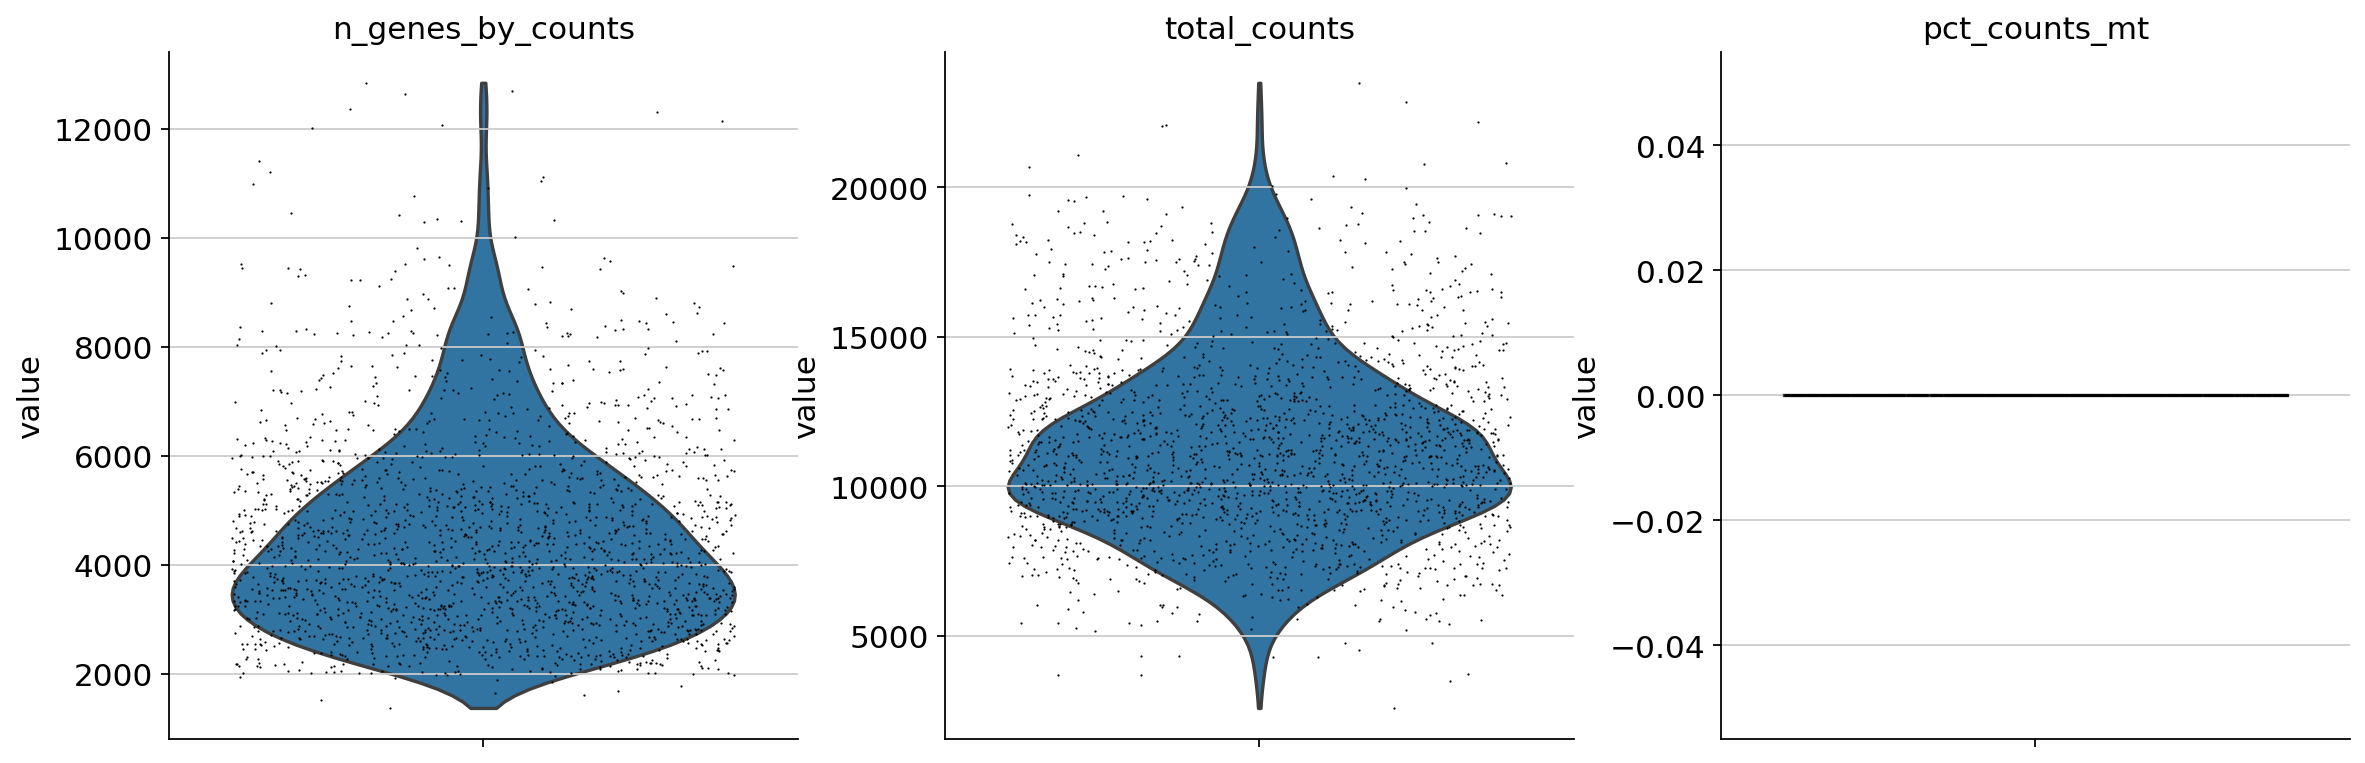

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)


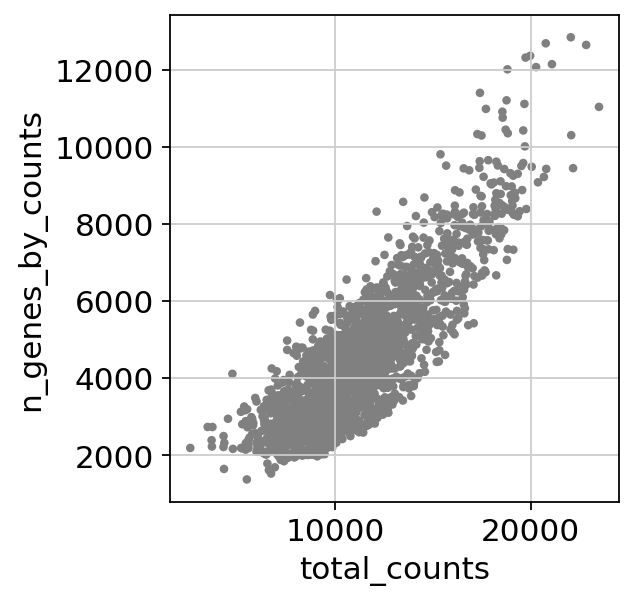

In [ ]:
#sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt') #No mit Percentage
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [ ]:
#instead of picking subjectively, you can use quanitle
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
lower_lim = np.quantile(adata.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim} to {upper_lim}')

2083.9 to 9222.56


In [ ]:
#adata = adata[adata.obs.n_genes_by_counts < 7000, :] #example if you wanted to pick a number yourself
adata = adata[(adata.obs.n_genes_by_counts < upper_lim) & (adata.obs.n_genes_by_counts > lower_lim)]
#adata = adata[adata.obs.pct_counts_mt < 20] #for mct  percentage

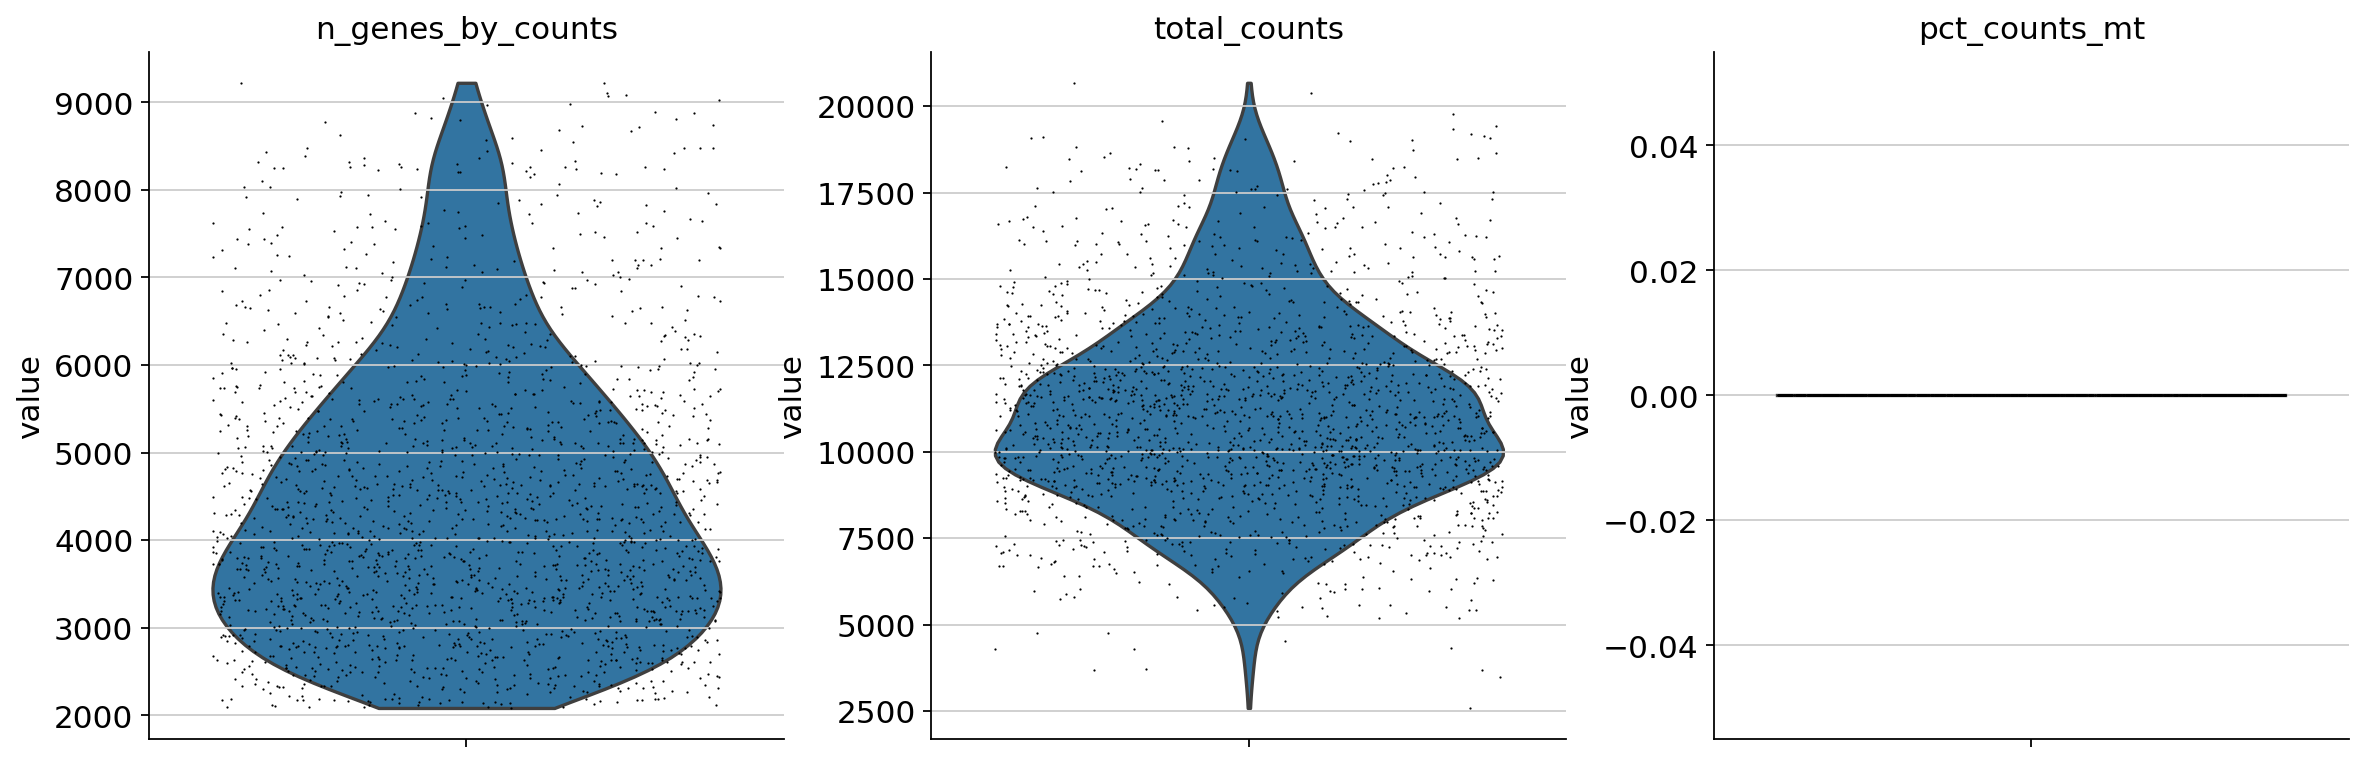

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)


In [ ]:
adata

View of AnnData object with n_obs × n_vars = 1920 × 21883
    obs: 'tumor', 'Malignant', 'Non_malignant', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [ ]:
#Don't run for this data
#sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10,000 UMI

In [ ]:
#sc.pp.log1p(adata) #change to log counts

normalizing counts per cell
    finished (0:00:00)


/usr/local/lib/python3.10/dist-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


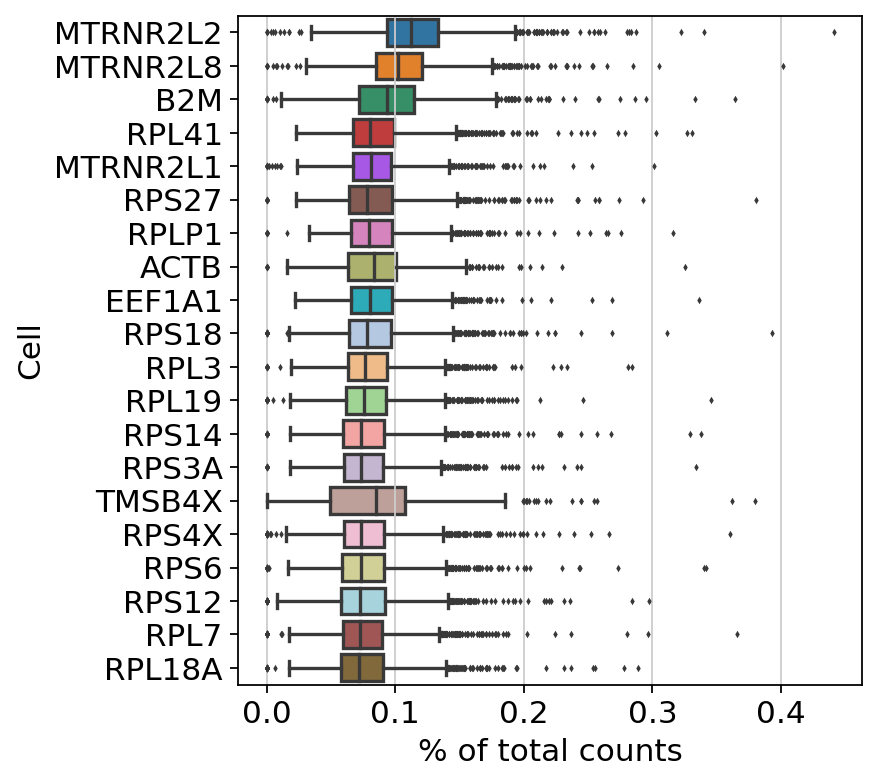

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20, )
#Show those genes that yield the highest fraction of counts in each single cell, across all cells.

### HVG

In [ ]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5) #these are default values
#minimum mean expression threshold
#max mean expression threshold
#minimum dispersion threshold.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [ ]:
adata.var[adata.var.highly_variable==True]

,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
Cell,,,,,,,,,,
KLHL13,62,False,62,0.063534,96.90,127.067089,True,0.515950,4.909373,0.848930
AEN,476,False,476,0.647298,76.20,1294.596583,True,2.796834,6.422169,0.631277
SLC10A7,217,False,217,0.246487,89.15,492.973602,True,1.658512,5.860938,0.738383
OR2K2,8,False,8,0.011444,99.60,22.888130,True,0.447756,6.301598,1.992649
MMP7,17,False,17,0.019949,99.15,39.898270,True,1.483062,8.557960,3.807428
...,...,...,...,...,...,...,...,...,...,...
ARMCX2,221,False,221,0.312463,88.95,624.926627,True,1.894741,5.658090,0.507556
DAZ4,17,False,17,0.020488,99.15,40.975650,True,0.216147,4.729505,0.701168
GPR15,23,False,23,0.047228,98.85,94.456670,True,1.555200,7.214361,2.278495


In [ ]:
adata.raw = adata #save raw data before processing values and further filtering

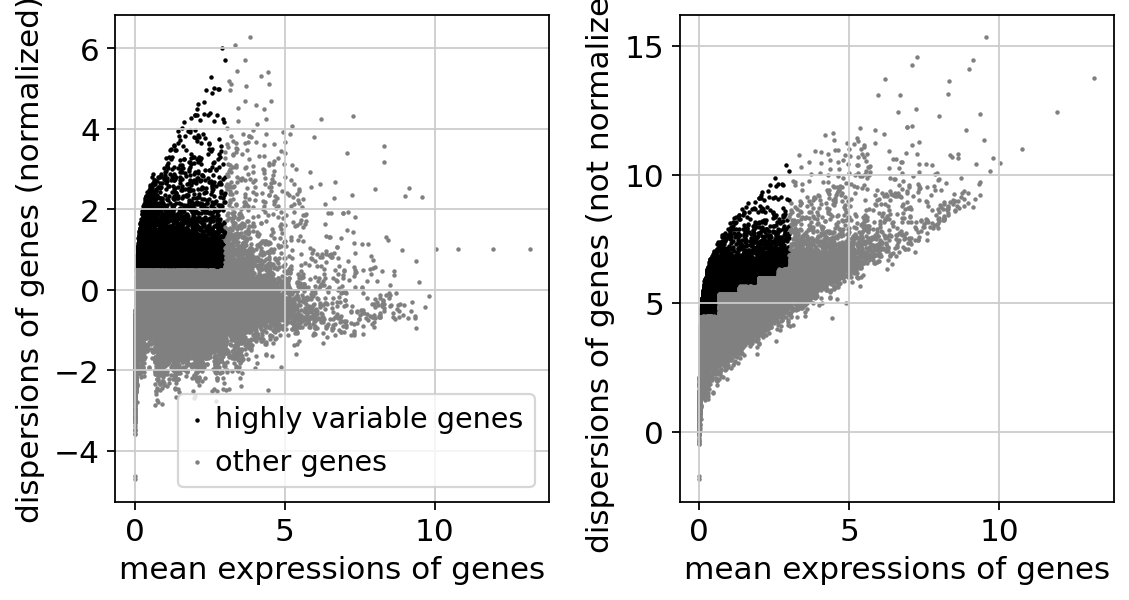

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
adata = adata[:, adata.var.highly_variable] #filter highly variable

In [ ]:
# The session crashed
#sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt']) #Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed

In [ ]:
sc.pp.scale(adata, max_value=10) #scale each gene to unit variance

/usr/local/lib/python3.10/dist-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
adata.X.min(), adata.raw.X.min()

(-1.1334327920592262, 0.0)

## Dimensionality Reduction by PCA

In [ ]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:02)


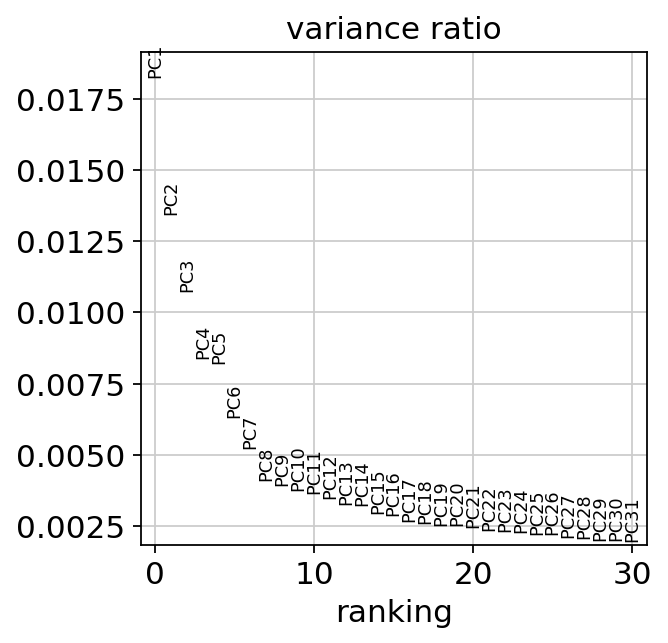

In [ ]:
sc.pl.pca_variance_ratio(adata)

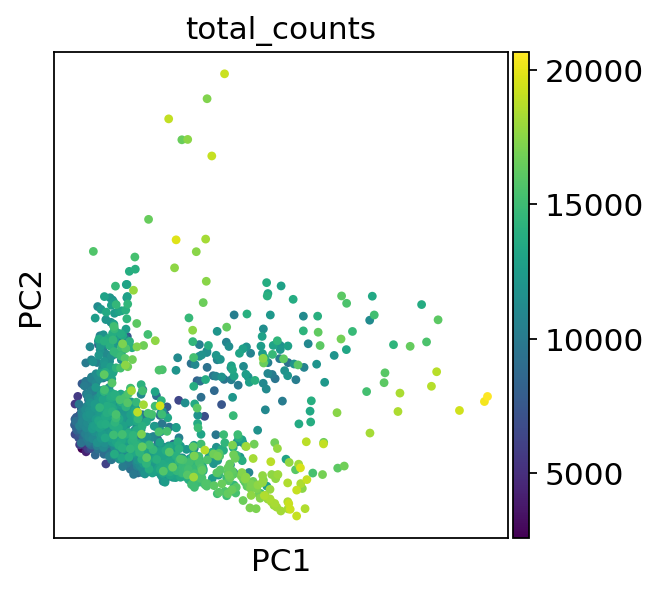

In [ ]:
# scatter plot in the PCA coordinates
sc.pl.pca_scatter(adata, color="total_counts")

##Computing the neighborhood graph


In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=8)


computing neighbors
    using 'X_pca' with n_pcs = 8
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


### Non_linear Dimensionality Reduction by UMAP


In [ ]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:02)


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


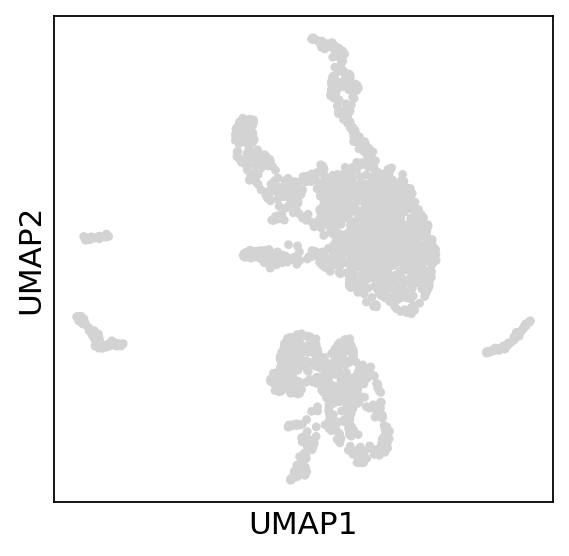

In [ ]:
sc.pl.umap(adata)

running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


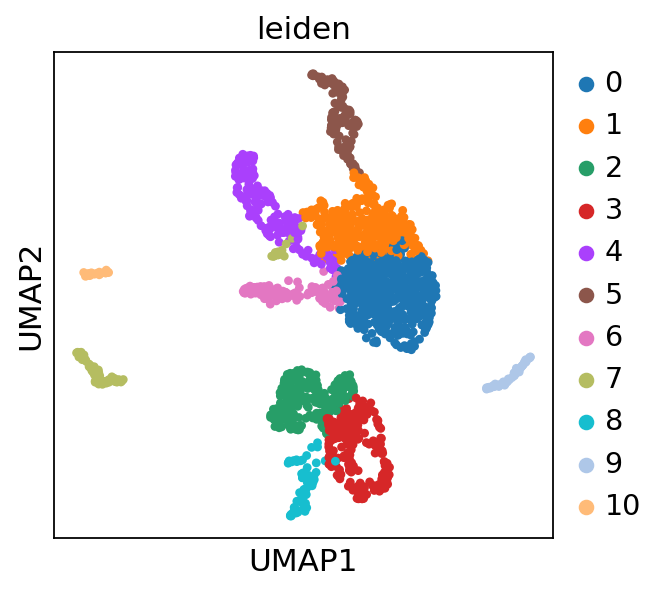

In [ ]:
sc.tl.leiden(adata, resolution = 0.40)
sc.pl.umap(adata, color=['leiden'])

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


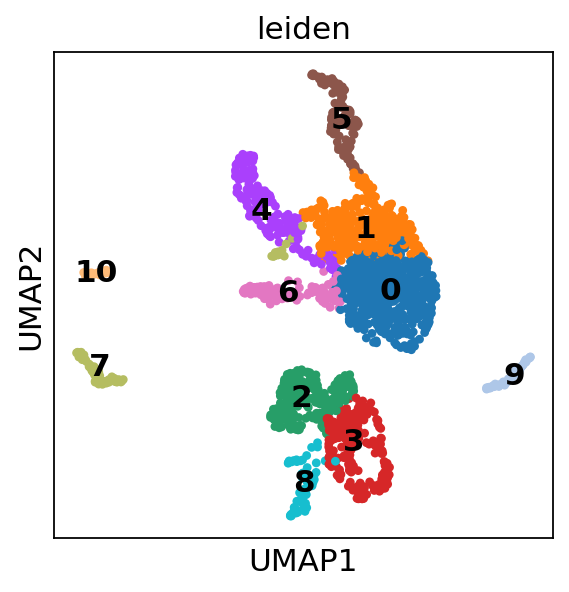

In [ ]:
sc.pl.umap(
    adata,
    color=["leiden"],
    legend_loc="on data",
)

## Find Markers

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


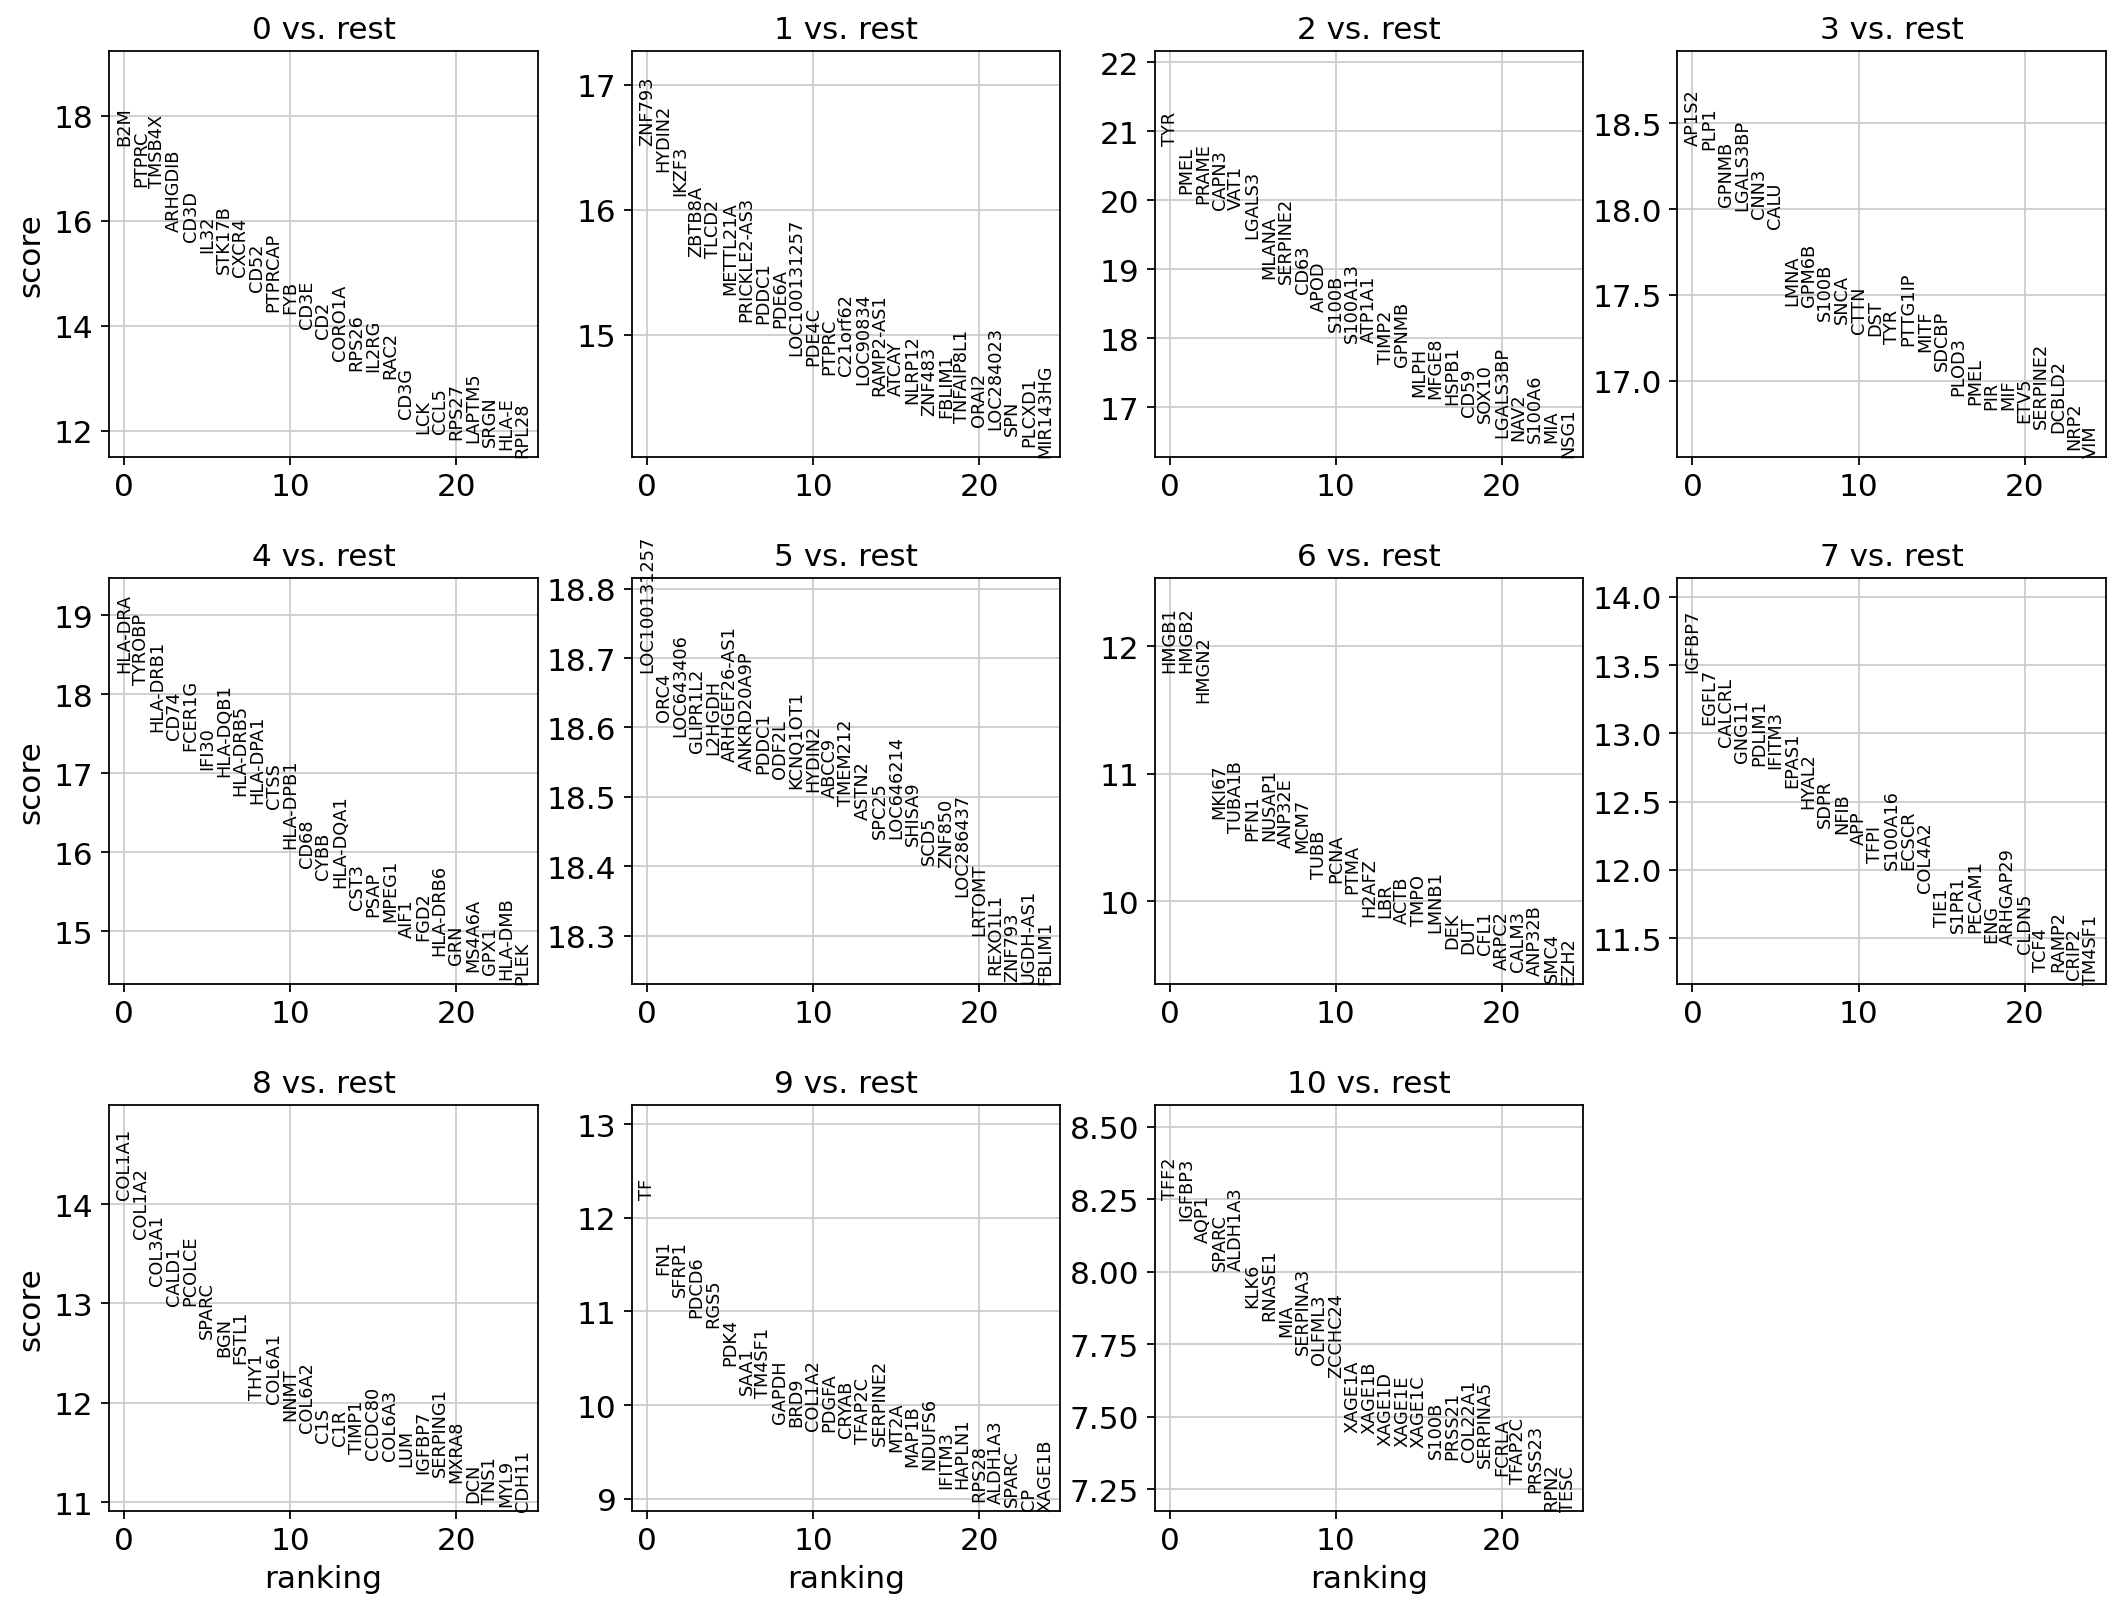

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


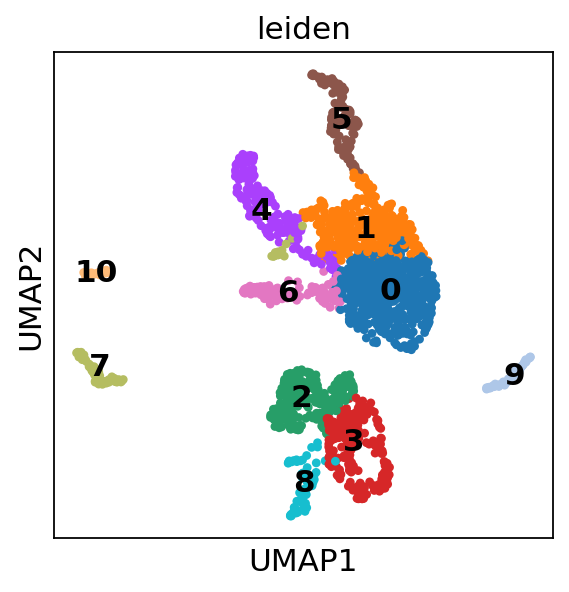

In [ ]:
sc.pl.umap(adata, color = ['leiden'], frameon = True, legend_loc = "on data")


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


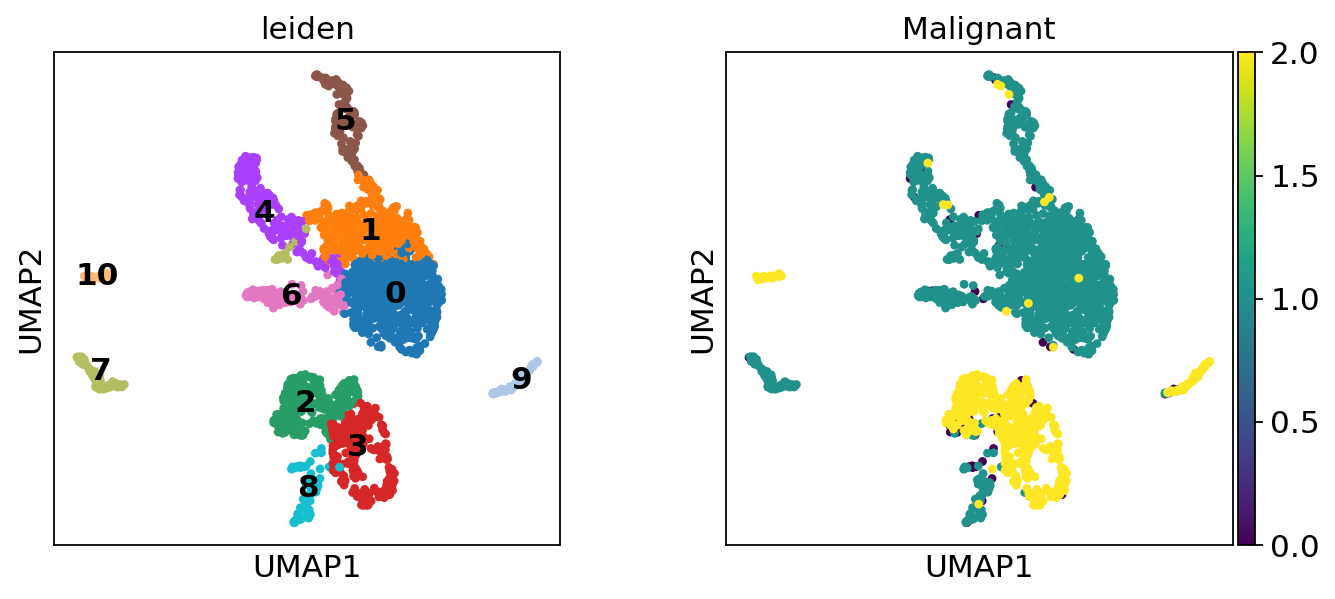

In [ ]:
sc.pl.umap(adata, color = ['leiden','Malignant'], frameon = True, legend_loc = "on data")

In [ ]:
Markers = sc.get.rank_genes_groups_df(adata, None)
Markers = Markers[(Markers.pvals_adj < 0.05) & (Markers.logfoldchanges > .5)]
Markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,B2M,17.444622,2.307384,3.782177e-68,4.138269e-64
1,0,PTPRC,16.659397,3.627450,2.586179e-62,8.084766e-59
2,0,TMSB4X,16.636122,4.431050,3.815406e-62,1.043657e-58
3,0,ARHGDIB,15.806452,4.015681,2.808466e-56,4.389832e-53
4,0,CD3D,15.618331,4.566719,5.461698e-55,7.469896e-52
...,...,...,...,...,...,...
220300,10,DYSF,2.713560,3.001255,6.656460e-03,4.983350e-02
220301,10,DMD,2.712992,2.360496,6.667872e-03,4.988480e-02
220302,10,NDST1,2.712803,1.880919,6.671679e-03,4.989623e-02
220303,10,CSAG2,2.712425,3.410271,6.679301e-03,4.990206e-02


## Manual Cell Type Annotation

In [ ]:
# for i in range(0,11):
#   print(f'"{i}": "",')

"0": "",
"1": "",
"2": "",
"3": "",
"4": "",
"5": "",
"6": "",
"7": "",
"8": "",
"9": "",
"10": "",


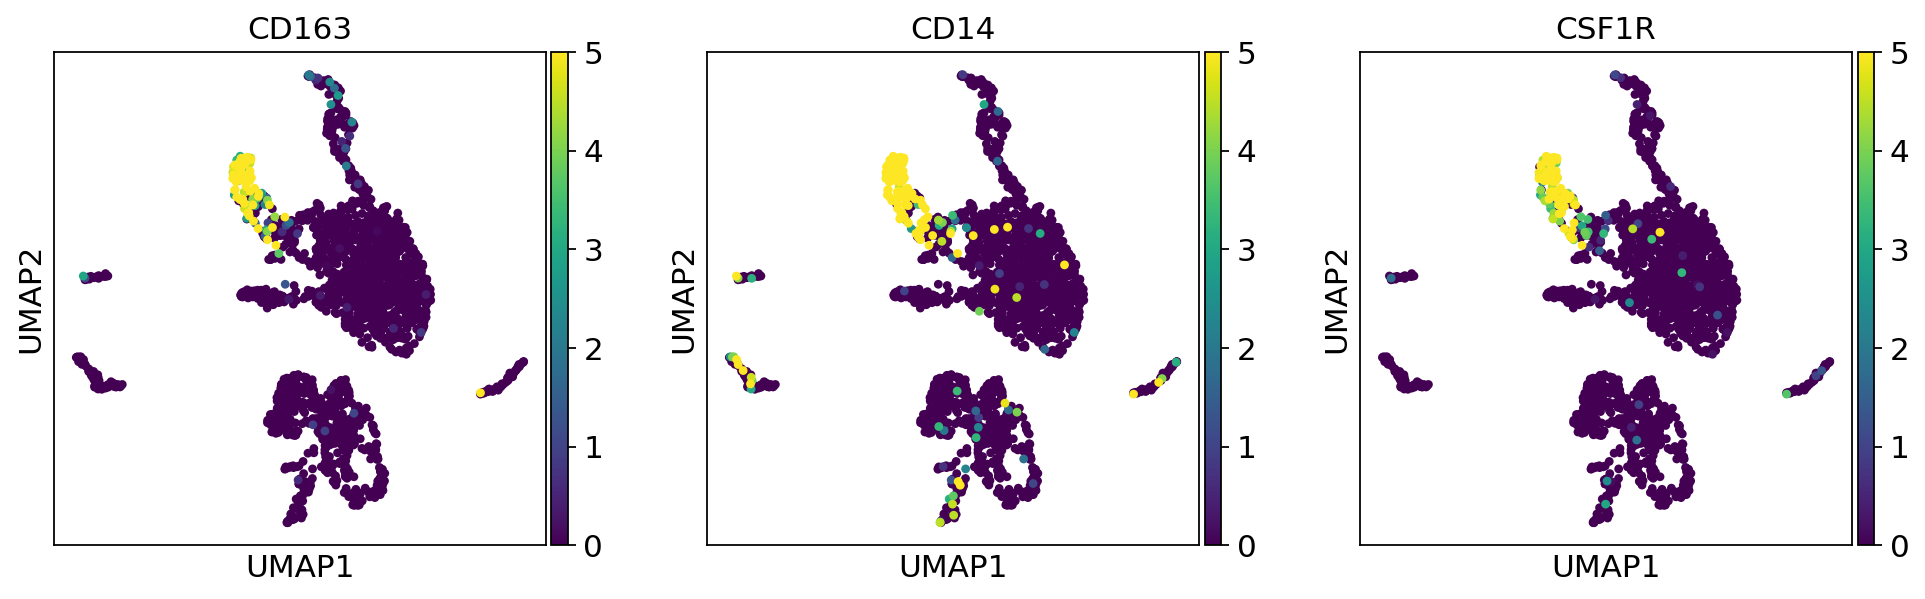

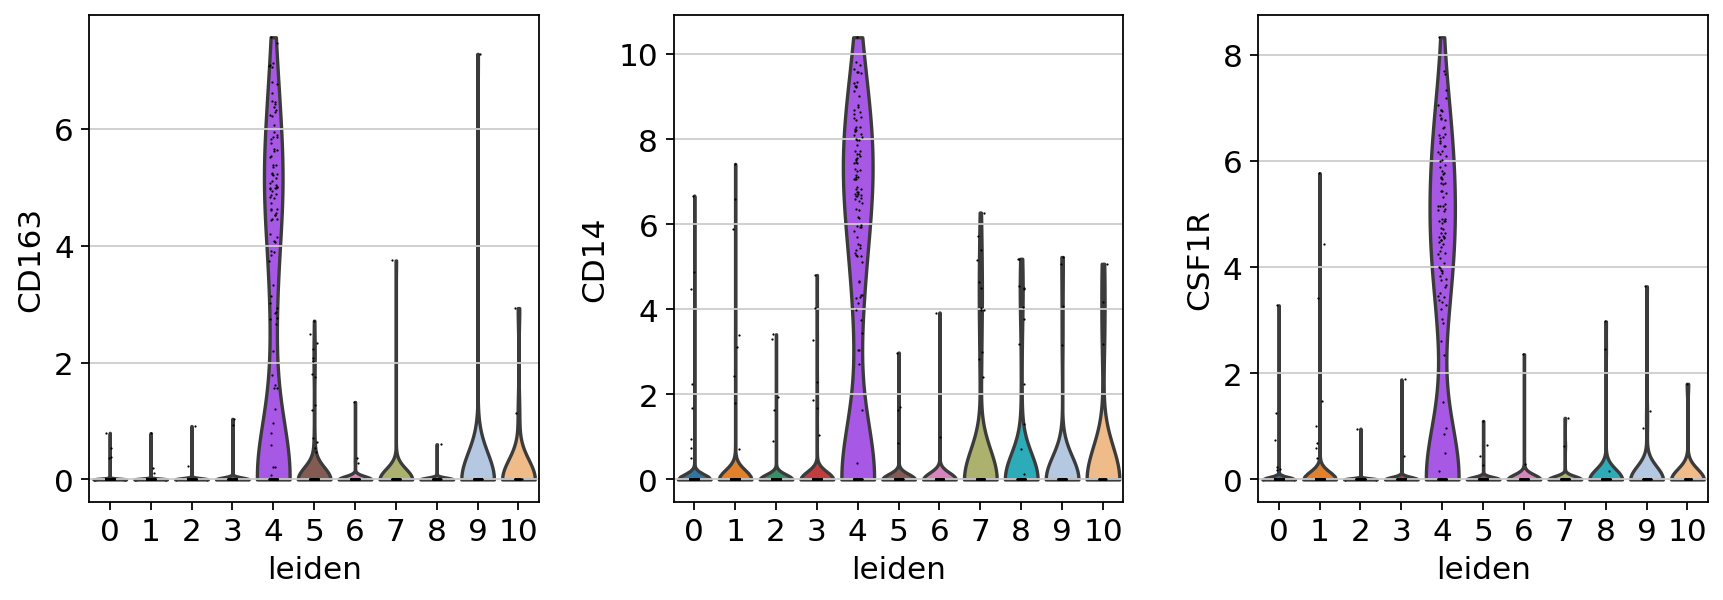

In [ ]:
#Markers of Macrophage
sc.pl.umap(adata, color = ['CD163','CD14','CSF1R'], frameon = True, vmax = 5)
sc.pl.violin(adata, ['CD163','CD14','CSF1R'], groupby='leiden', use_raw = True)

#cluster 4 is Macrophage

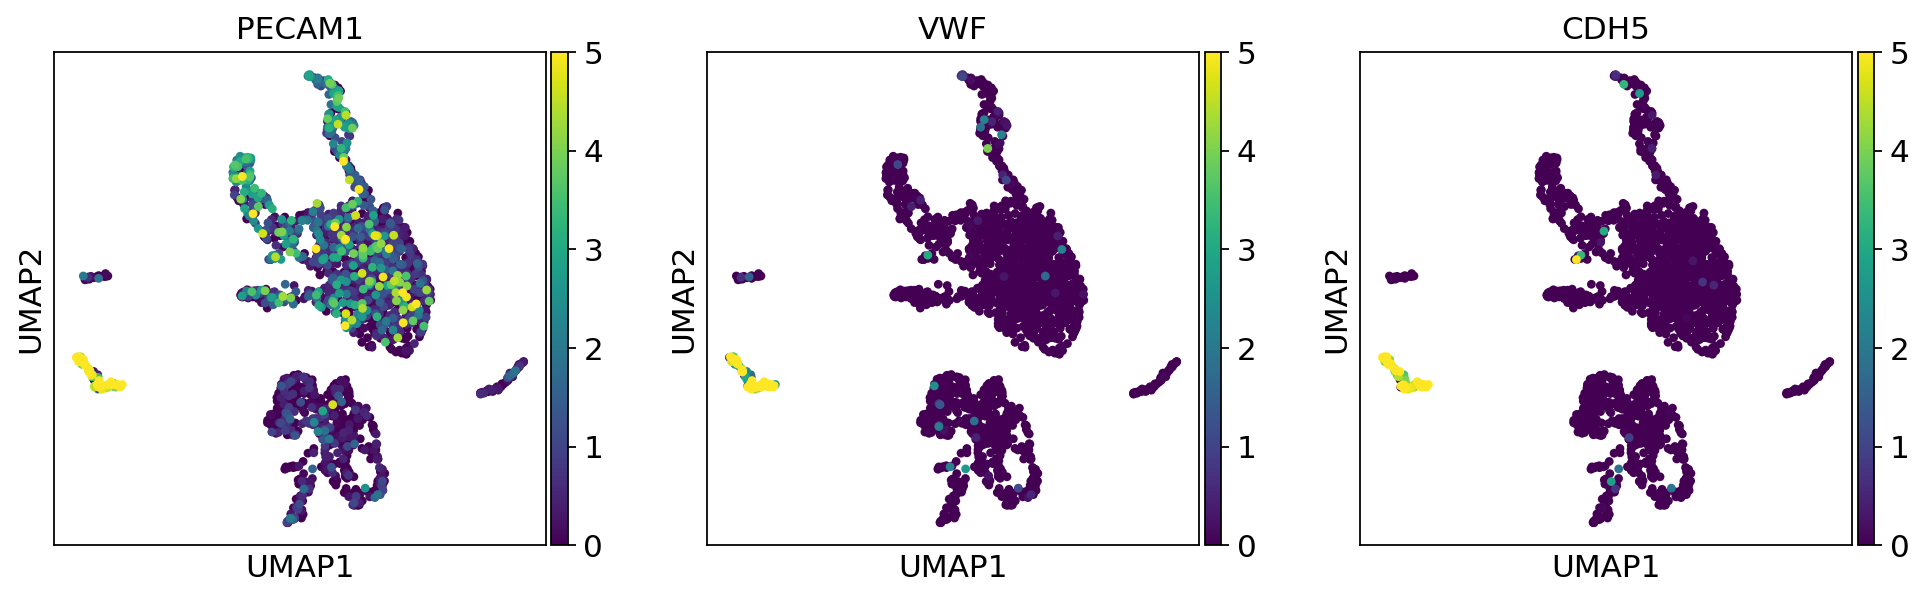

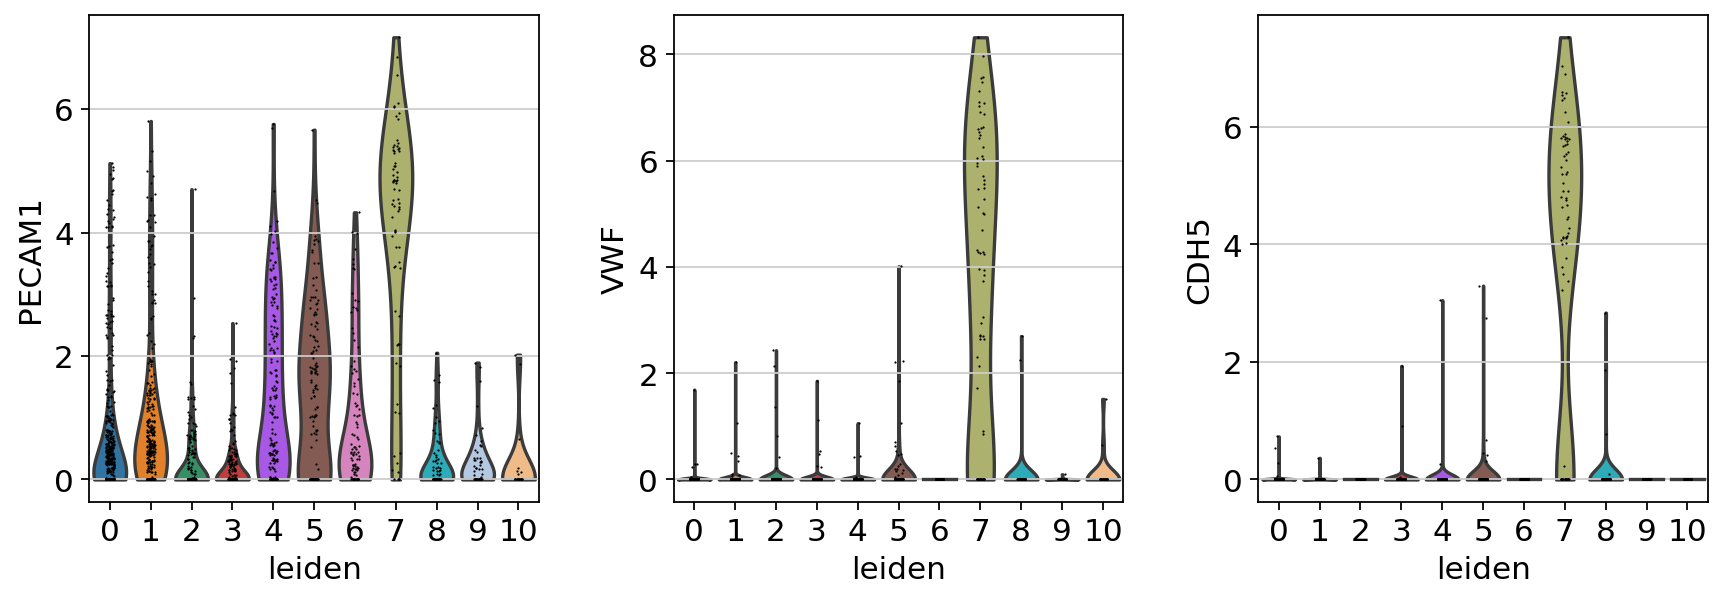

In [ ]:
#EndoThelial Cells
sc.pl.umap(adata, color = ['PECAM1','VWF','CDH5'], frameon = True, vmax = 5)
sc.pl.violin(adata, ['PECAM1','VWF','CDH5'], groupby='leiden', use_raw = True)

# 7 is endothelial

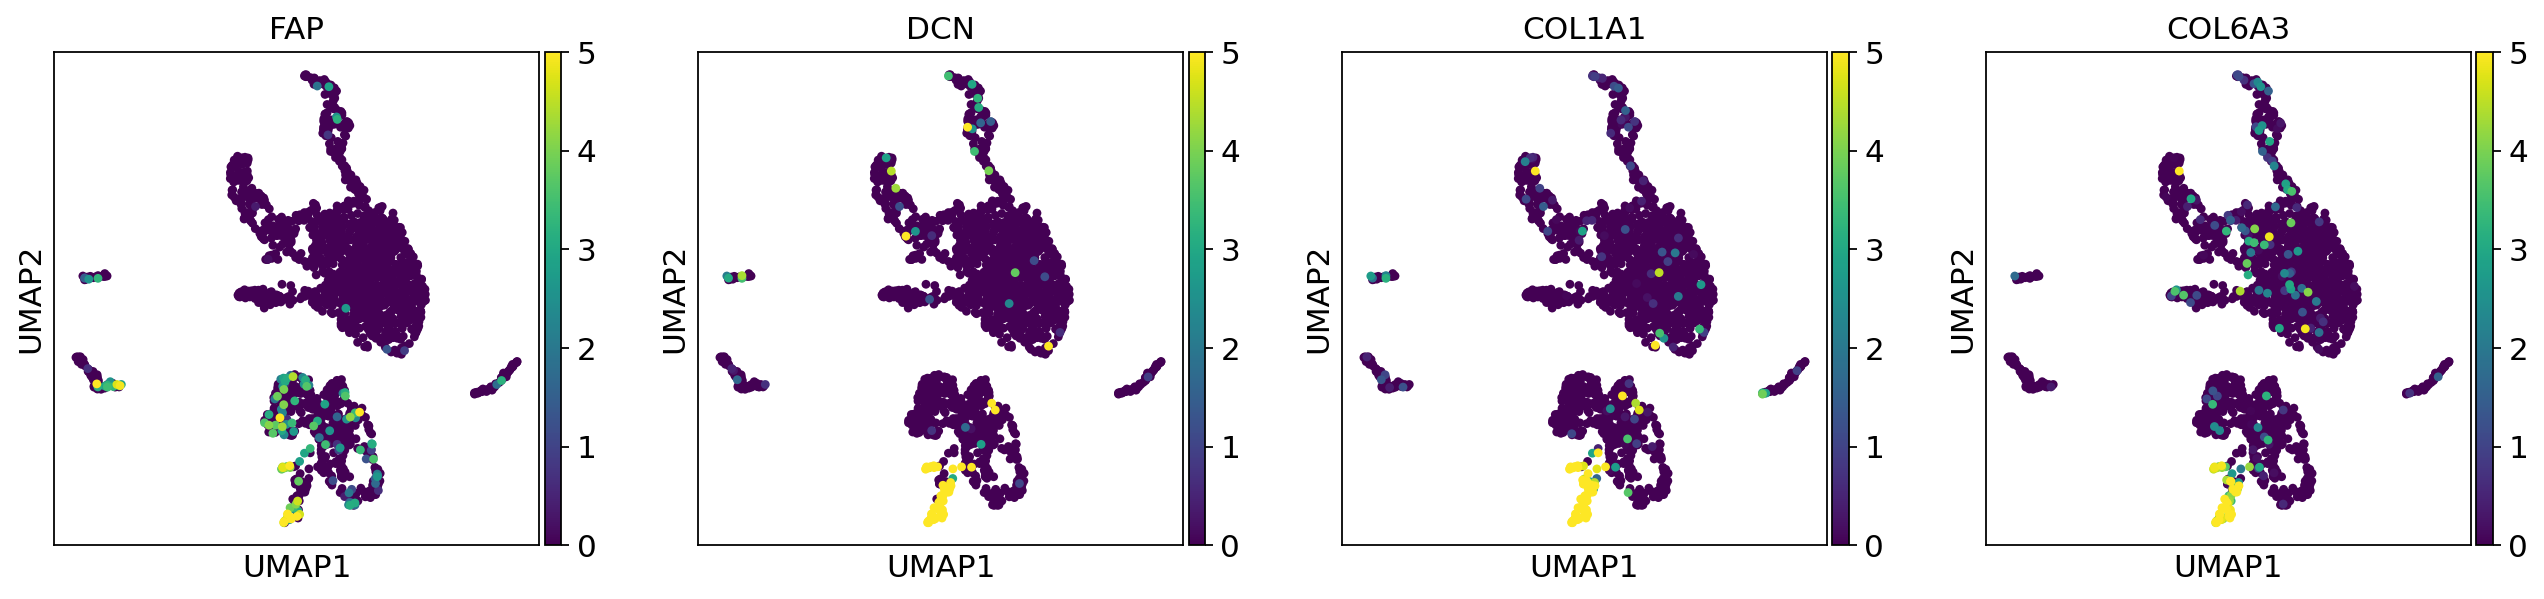

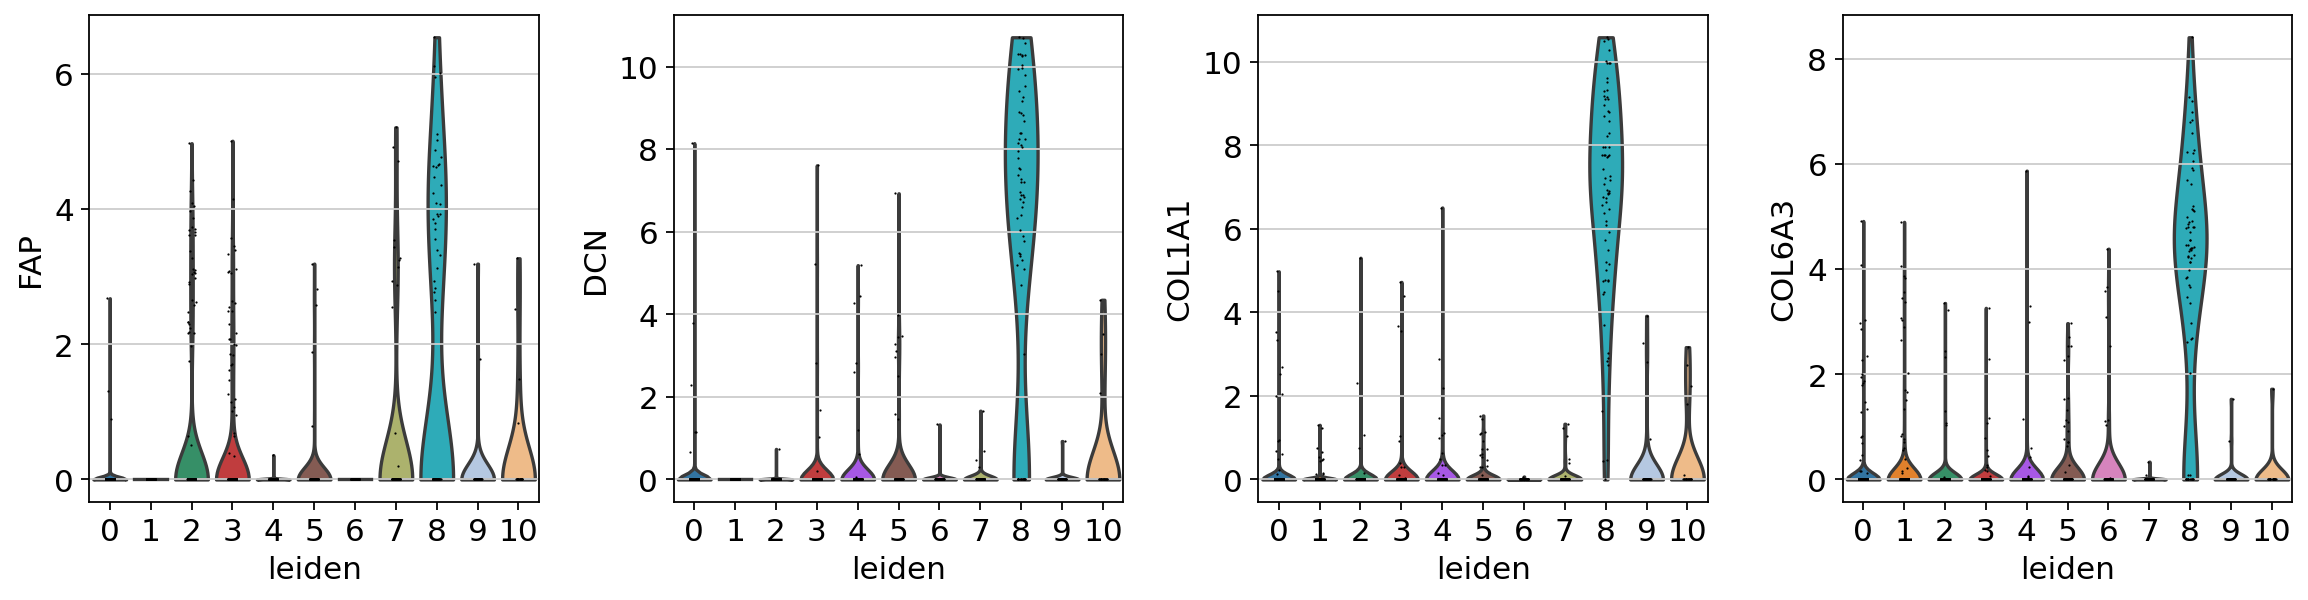

In [ ]:
#CAFs
sc.pl.umap(adata, color = ['FAP','DCN','COL1A1','COL6A3'], frameon = True, vmax = 5)
sc.pl.violin(adata, ['FAP','DCN','COL1A1','COL6A3'], groupby='leiden', use_raw = True)

#Cluster 8 is CAFs


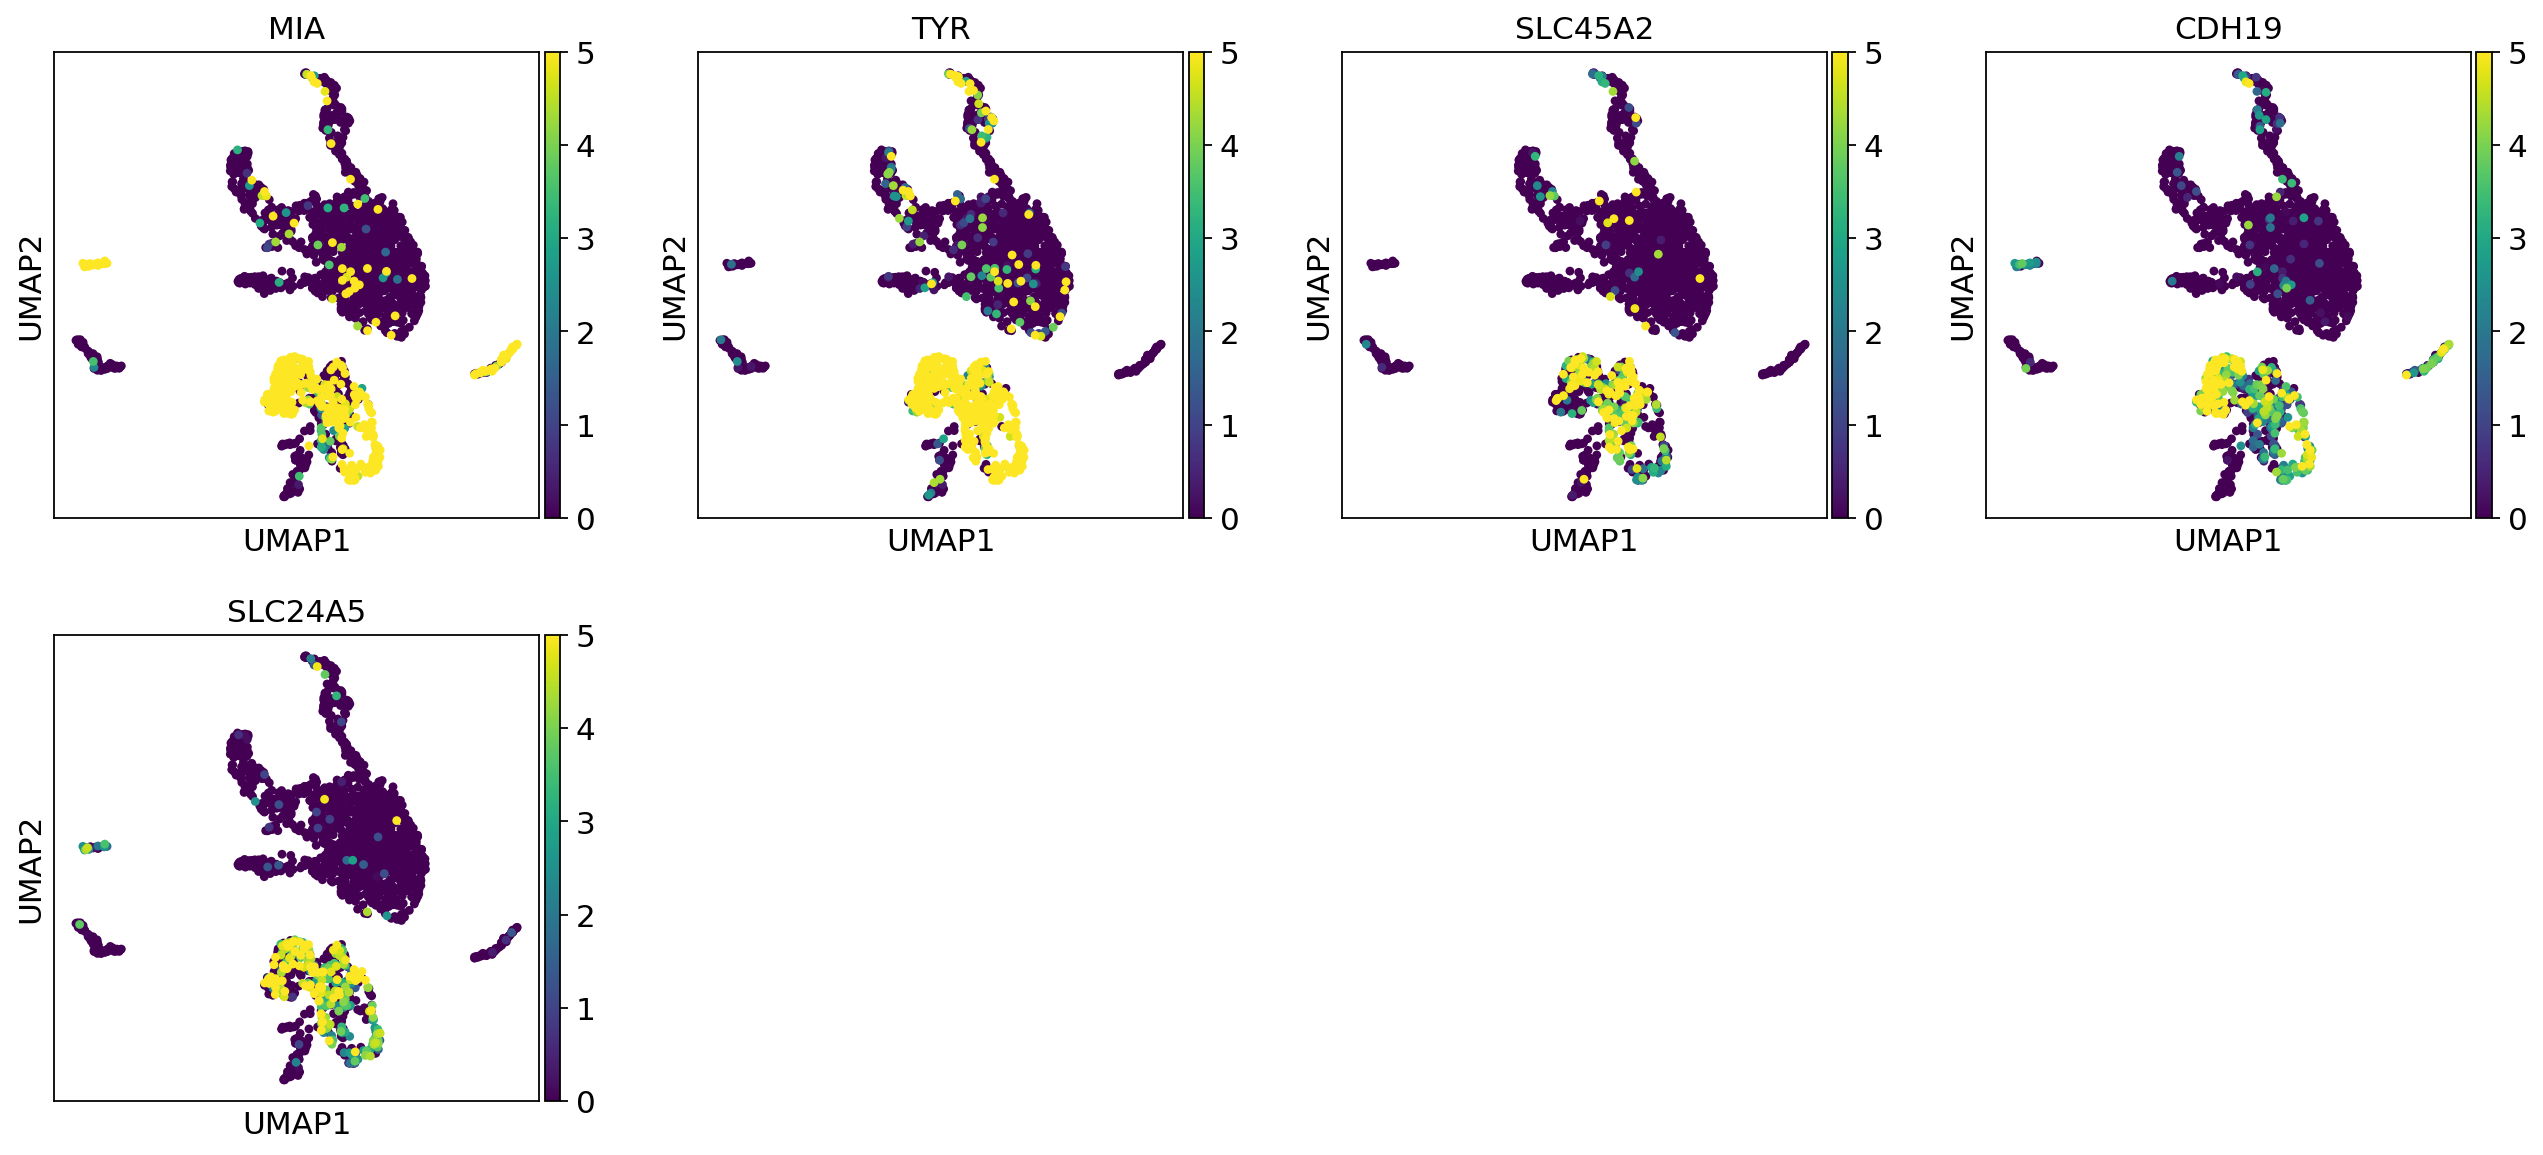

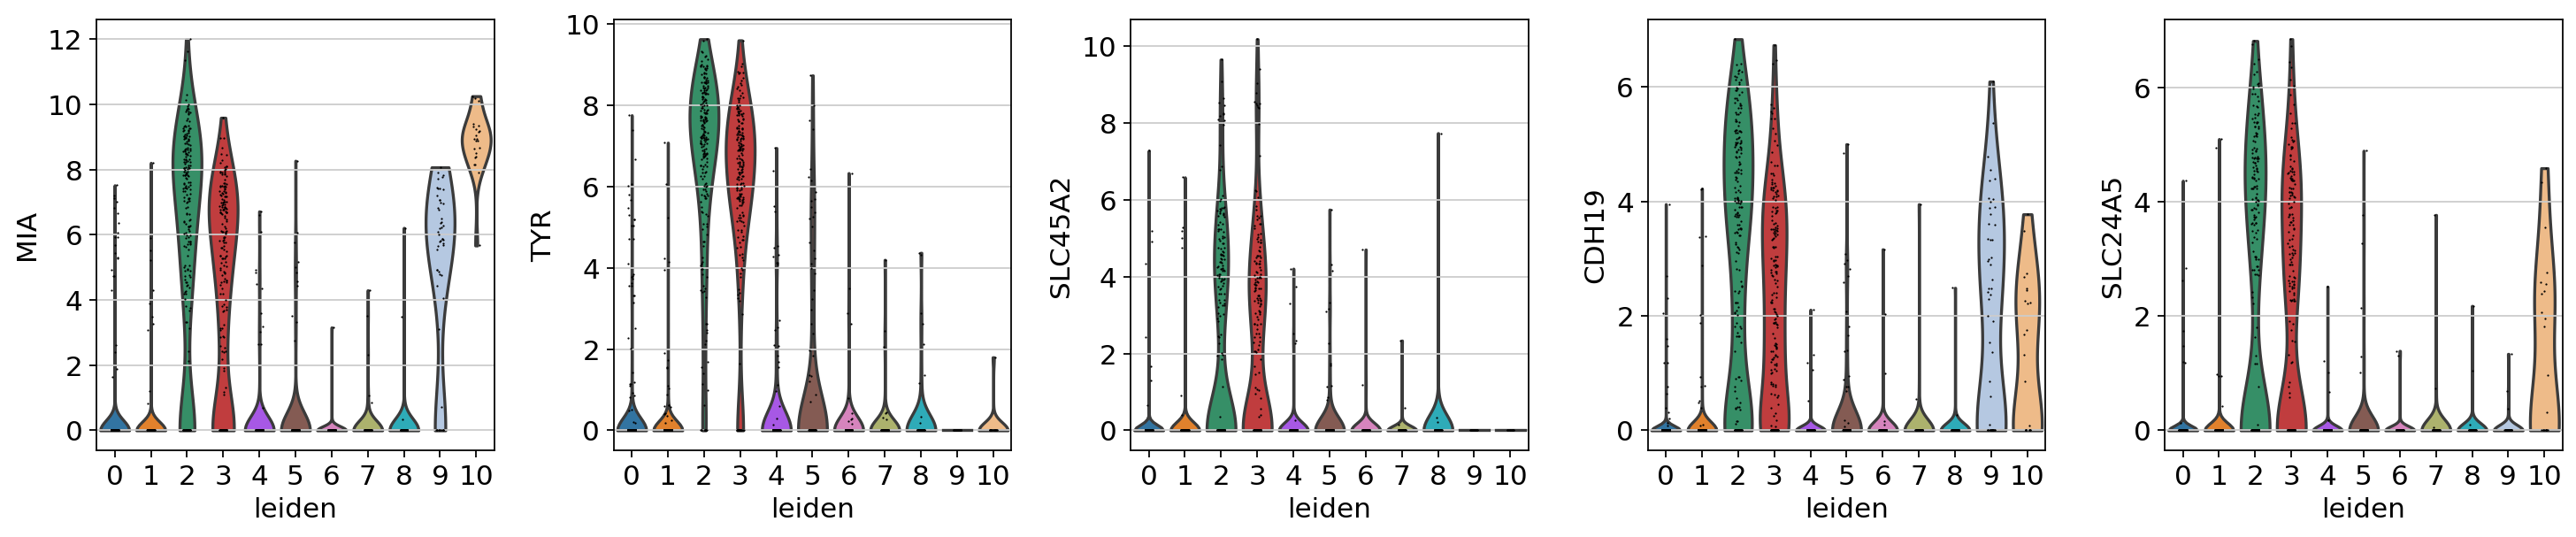

In [ ]:
#Melanoma
sc.pl.umap(adata, color = ['MIA','TYR','SLC45A2','CDH19','SLC24A5'], frameon = True, vmax = 5)
sc.pl.violin(adata, ['MIA','TYR','SLC45A2','CDH19','SLC24A5'], groupby='leiden', use_raw = True)

#Cluster 2,3,9,10 are melanomas

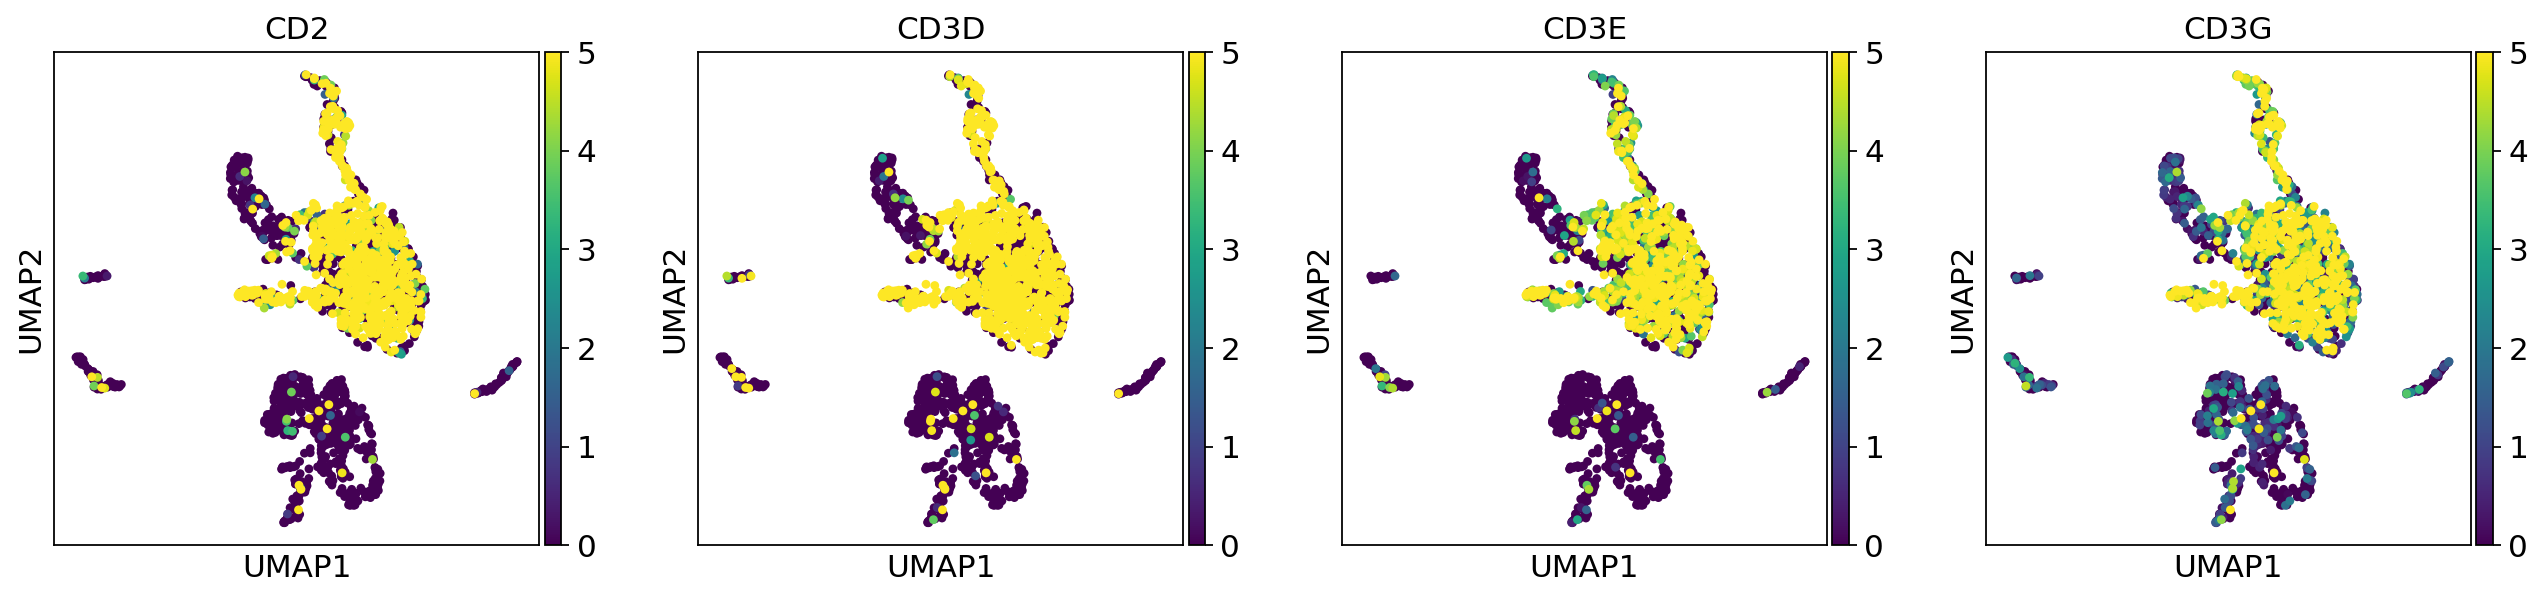

In [ ]:
#T-Cells Markers
sc.pl.umap(adata, color = ['CD2','CD3D','CD3E','CD3G'], frameon = True, vmax = 5)
#clusters 0,1,5,6

In [ ]:
#Check scores for CD8A
Markers[Markers.names == 'CD8A']

,group,names,scores,logfoldchanges,pvals,pvals_adj
171,0,CD8A,6.246445,2.198912,4.198994e-10,3.888556e-09
22714,1,CD8A,7.852972,2.856543,4.062930e-15,9.488697e-14
112278,5,CD8A,4.112288,2.150595,3.917565e-05,2.613661e-04
131714,6,CD8A,5.321063,3.413940,1.031629e-07,5.126906e-06


In [ ]:
#Check scores for CD4
Markers[Markers.names == 'CD4']

,group,names,scores,logfoldchanges,pvals,pvals_adj
87585,4,CD4,12.569685,4.833459,3.099560e-36,1.256068e-33


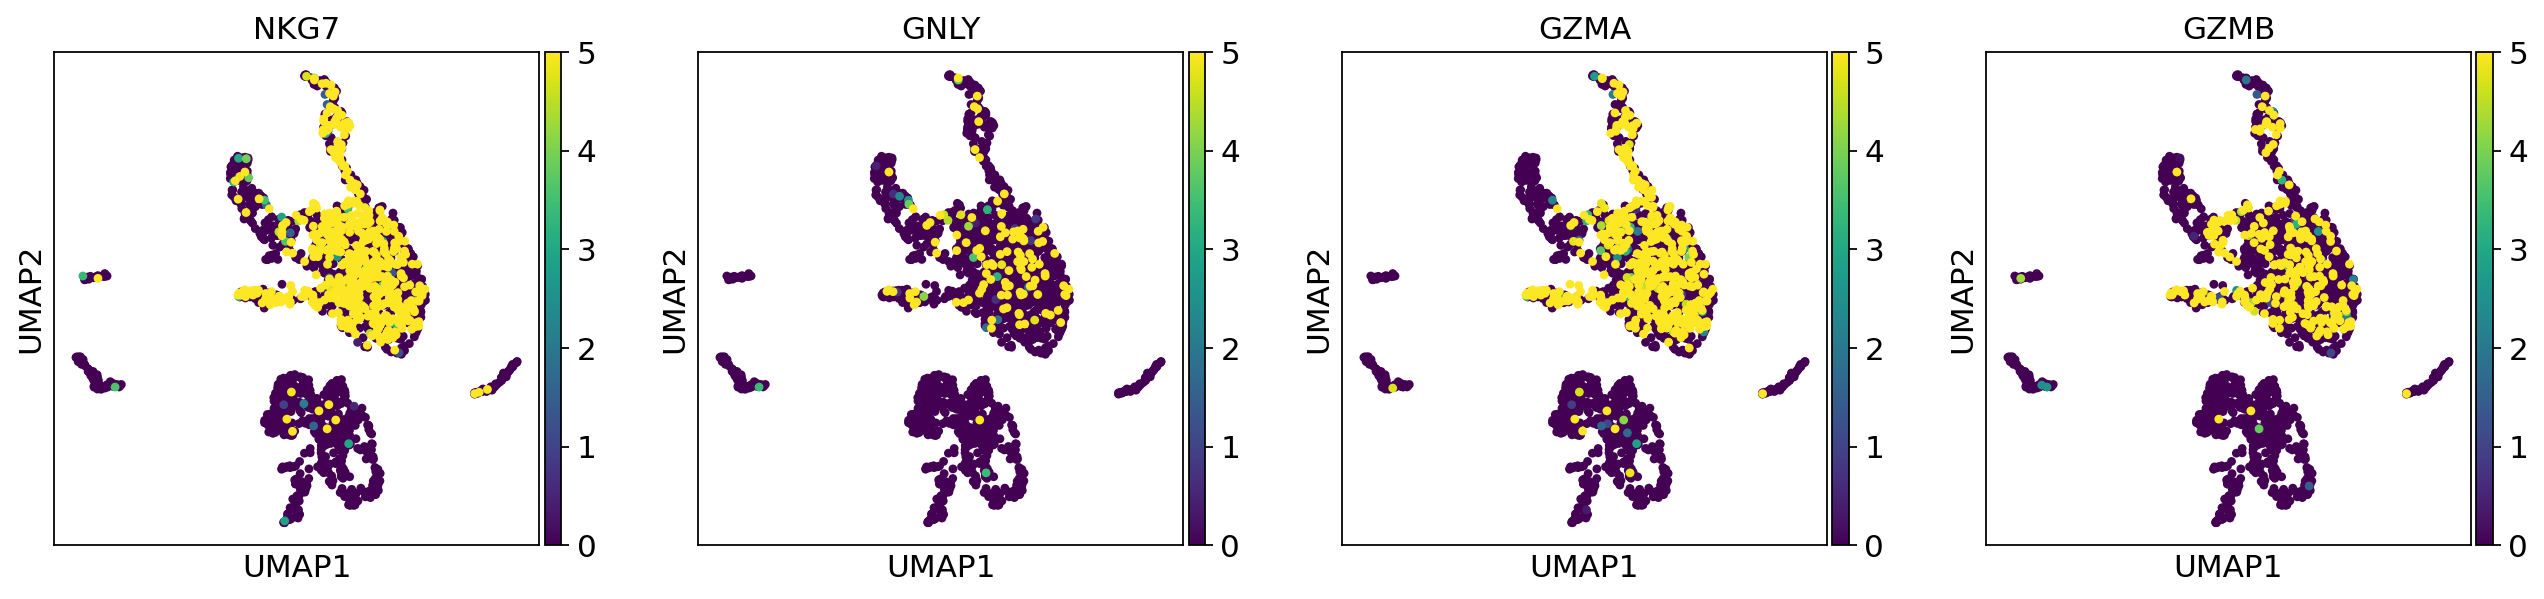

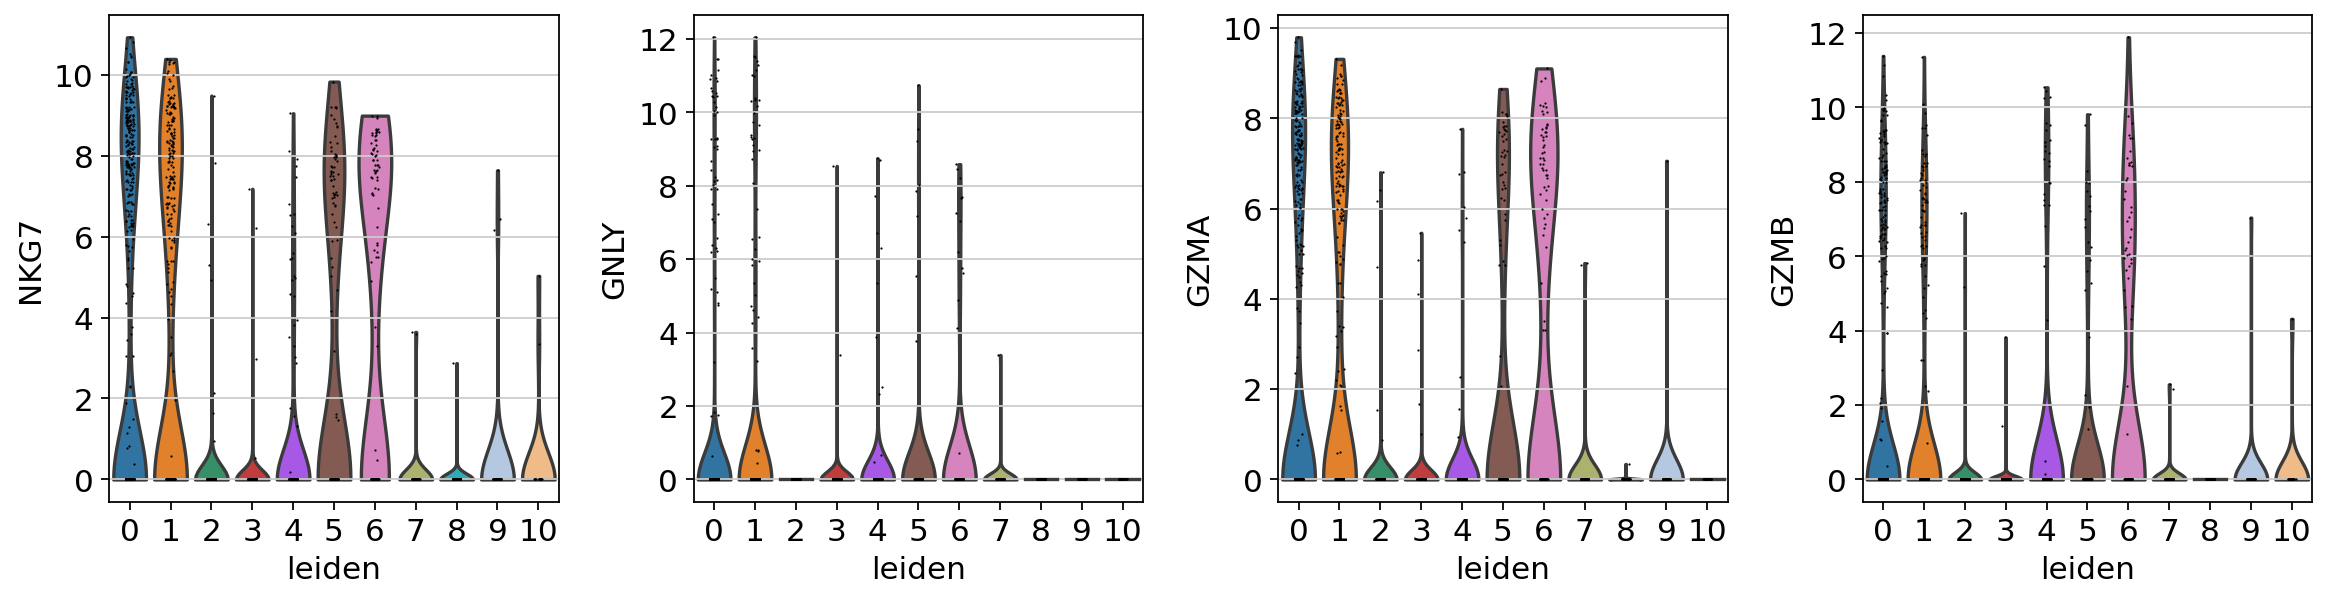

In [ ]:
#NK Cells
sc.pl.umap(adata, color = ["NKG7","GNLY"	,"GZMA","GZMB"], frameon = True, vmax = 5)
sc.pl.violin(adata, [ "NKG7","GNLY"	,"GZMA","GZMB"], groupby='leiden', use_raw = True)

#Cluster 0,1,5,6 has NK cells

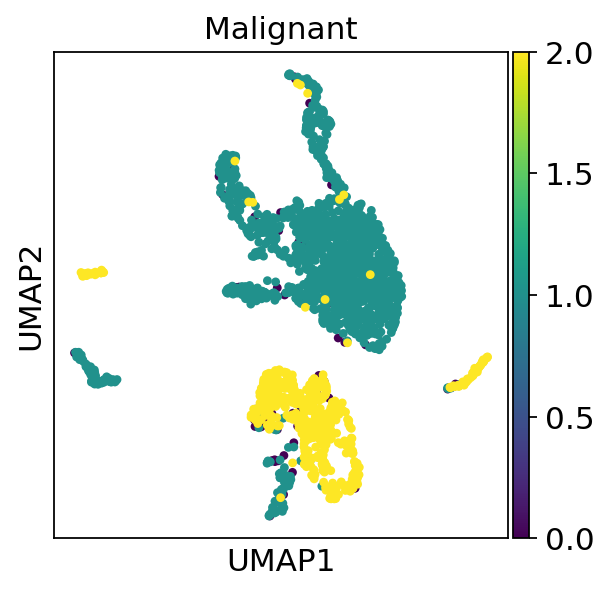

In [ ]:
sc.pl.umap(adata, color = ['Malignant'], frameon = True, legend_loc = "on data")


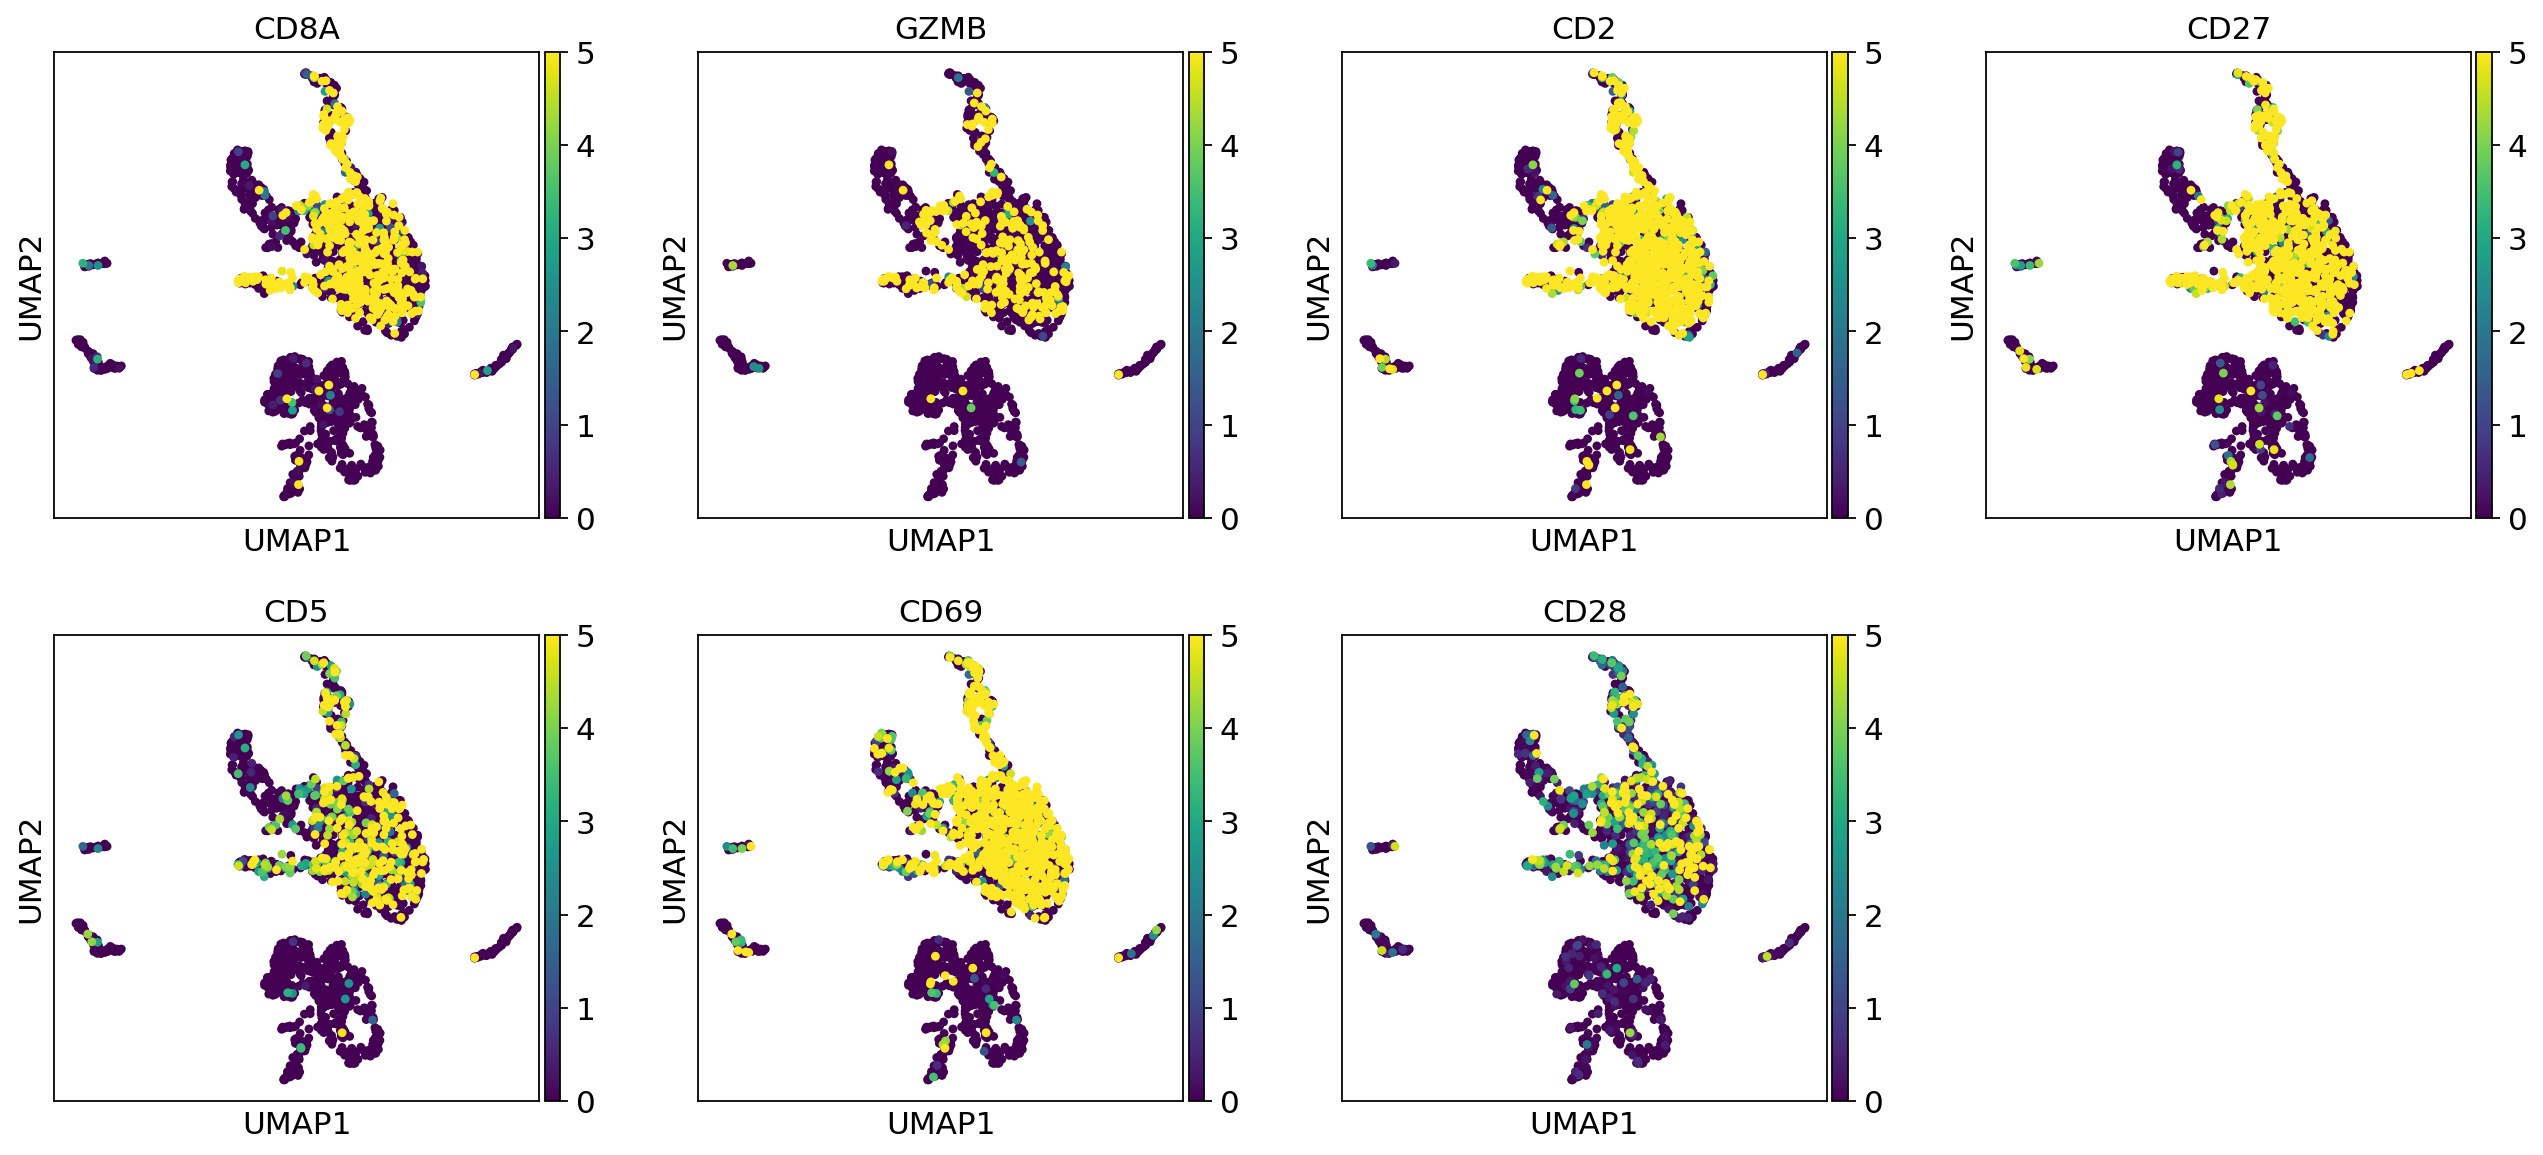

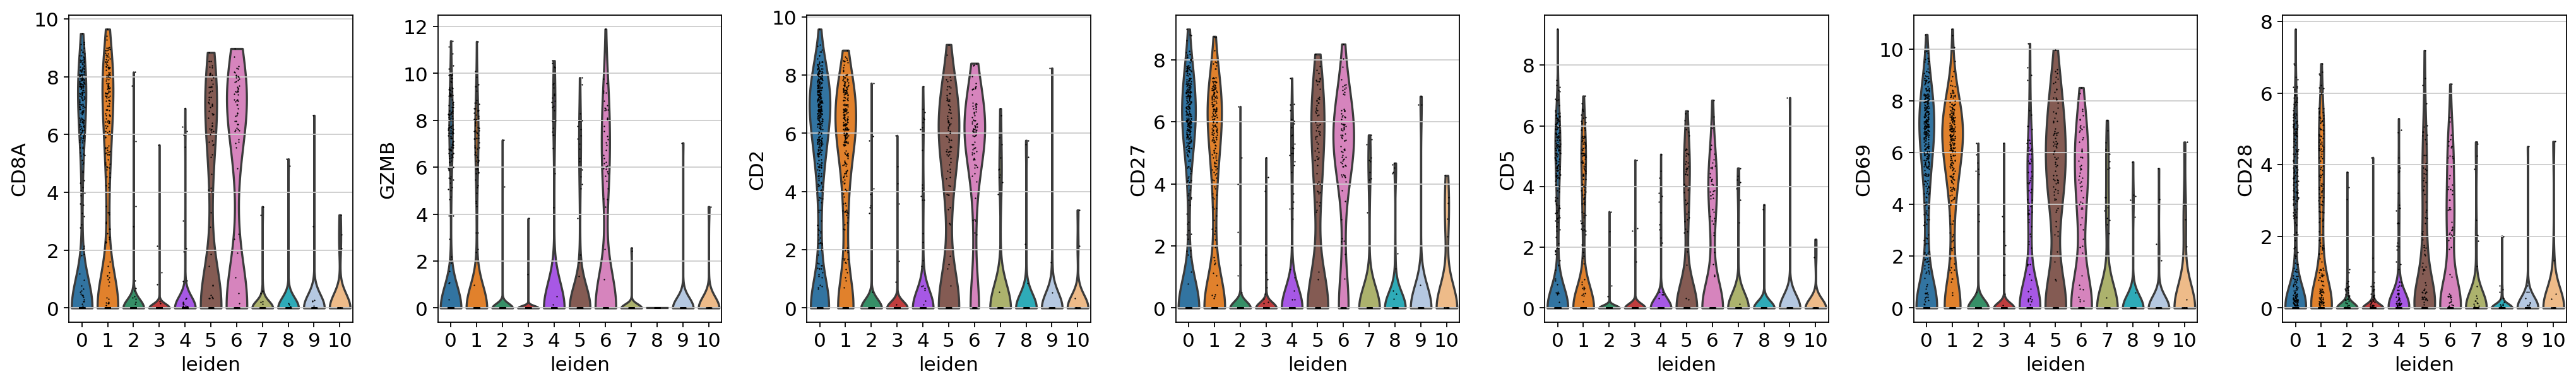

In [ ]:
#CD8+ T Cells
sc.pl.umap(adata, color = ["CD8A","GZMB","CD2","CD27","CD5","CD69","CD28"], frameon = True, vmax = 5)
sc.pl.violin(adata, [ "CD8A","GZMB","CD2","CD27","CD5","CD69","CD28"], groupby='leiden', use_raw = True)

In [ ]:
Markers = Markers[(Markers.pvals_adj < 0.05) & (Markers.logfoldchanges > .5)]
cluster_1_markers = Markers.names[Markers.group == '1'][0:10].to_list()
cluster_1_markers

['PTPRCAP']

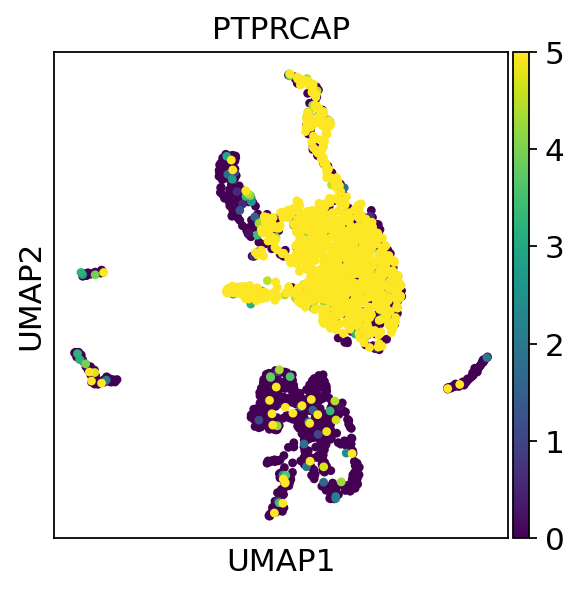

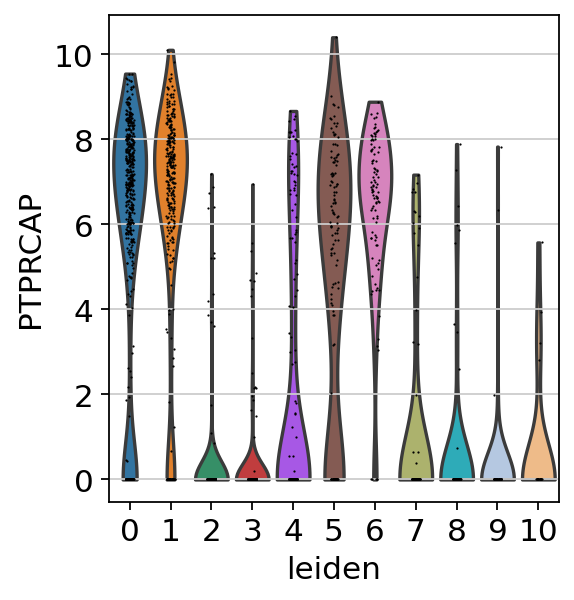

In [ ]:
#cluster_1_markers
sc.pl.umap(adata, color = cluster_1_markers, frameon = True, vmax = 5)
sc.pl.violin(adata, cluster_1_markers, groupby='leiden', use_raw = True)

In [ ]:
cell_type ={"0": "T_cells/NK",
"1": "T_cells/NK",
"2": "Mel",
"3": "Mel",
"4": "Macro", #Macrophage
"5": "T_cells/NK",
"6": "T_cells/NK",
"7": "Endo",  #Endothelial
"8": "CAFs",
"9": "Mel",
"10": "Mel"}

In [ ]:
adata.obs['cell_type'] = adata.obs.leiden.map(cell_type)


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


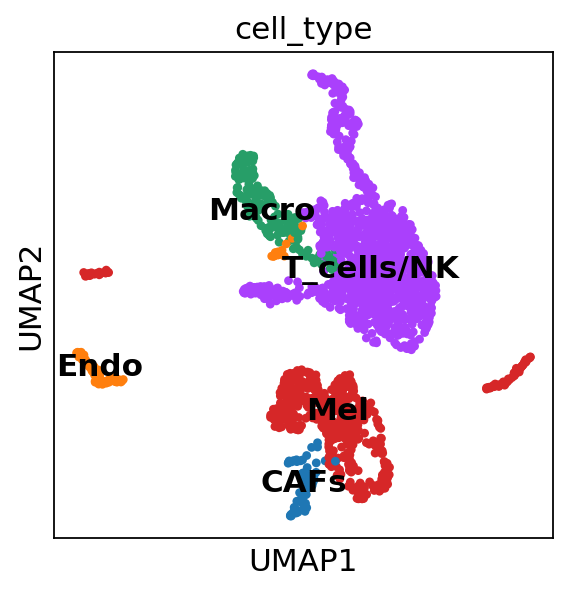

In [ ]:
sc.pl.umap(adata, color = ['cell_type'], frameon = True, legend_loc = "on data")


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


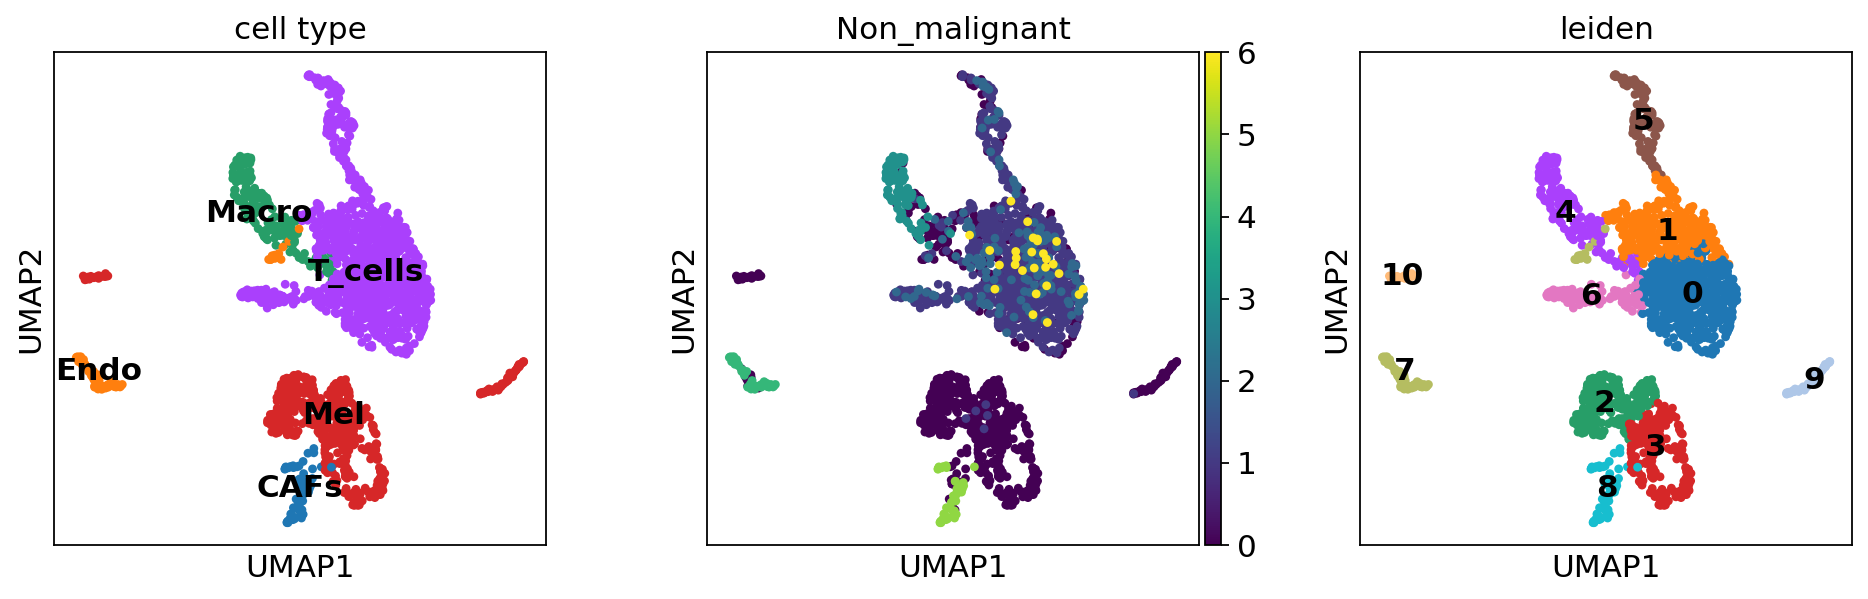

In [ ]:
sc.pl.umap(adata, color = ['cell_type','Non_malignant','leiden'], frameon = True, legend_loc = "on data")


## Saving the object as h5ad to Disk



In [ ]:
adata.obs['tumor'] = adata.obs['tumor'].astype('str')
adata.obs['Malignant'] = adata.obs['Malignant'].astype('str')
adata.obs['Non_malignant'] = adata.obs['Non_malignant'].astype('str')

In [ ]:
adata.write('adata.h5ad', compression="gzip")